# DA4131 – Advanced ML Applications for Business
## Buy, Sell or Hold? Market Outlook May 2026
### LSTM-Based Stock Price Prediction: Amazon | eBay | Etsy

---
**Course:** DA4131 – Advanced ML Applications for Business  
**Assignment:** Section 01 – LSTM Model Development  
**Data Period:** 1 April 2021 – 1 April 2026  
**Forecast Period:** 1 May 2026 – 14 May 2026  
**Structure:** Task 1 downloads all data. Task 2 performs combined EDA for all three companies. Tasks 3–5 are handled independently per company.

---

## 0. Install & Import Libraries

In [1]:
!pip install yfinance visualkeras keras scikit-learn matplotlib plotly pandas numpy seaborn keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import yfinance as yf

import keras
from keras import layers, callbacks

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import visualkeras

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.options.plotting.backend = 'plotly'

# ── Global Settings ───────────────────────────────────────────────────────────
WINDOW_SIZE   = 60          # 60-trading-day look-back window
TEST_SPLIT    = '2025-07-01'
FORECAST_DAYS = 10          # 1 May – 14 May 2026 (trading days)

# ── Colour palette for combined EDA ──────────────────────────────────────────
COLORS = {'AMZN': 'orange', 'EBAY': 'green', 'ETSY': 'blue'}
TICKERS = ['AMZN', 'EBAY', 'ETSY']

print('All libraries imported successfully.')
print(f'Keras version : {keras.__version__}')

All libraries imported successfully.
Keras version : 3.13.2


## TASK 1 — Download & Save Raw Data (All Three Stocks)
> All data is downloaded here using Yahoo Finance via Python.  
> Each stock is saved as an individual CSV and also merged into one combined CSV.

In [3]:
# ── Download from Yahoo Finance ───────────────────────────────────────────────
AMZN = yf.download("AMZN", start="2021-04-01", end="2026-04-01", auto_adjust=False)
EBAY = yf.download("EBAY", start="2021-04-01", end="2026-04-01", auto_adjust=False)
ETSY = yf.download("ETSY", start="2021-04-01", end="2026-04-01", auto_adjust=False)

AMZN.columns = AMZN.columns.get_level_values(0)
EBAY.columns = EBAY.columns.get_level_values(0)
ETSY.columns = ETSY.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
# ── Build individual clean DataFrames ─────────────────────────────────────────
amzn = pd.DataFrame({
    'Date':      AMZN.index,
    'Close':     AMZN['Close'].values.flatten(),
    'Adj_Close': AMZN['Adj Close'].values.flatten(),
    'Open':      AMZN['Open'].values.flatten(),
    'High':      AMZN['High'].values.flatten(),
    'Low':       AMZN['Low'].values.flatten(),
    'Volume':    AMZN['Volume'].values.flatten()
})
amzn.to_csv('amzn_Data.csv', index=False)

ebay = pd.DataFrame({
    'Date':      EBAY.index,
    'Close':     EBAY['Close'].values.flatten(),
    'Adj_Close': EBAY['Adj Close'].values.flatten(),
    'Open':      EBAY['Open'].values.flatten(),
    'High':      EBAY['High'].values.flatten(),
    'Low':       EBAY['Low'].values.flatten(),
    'Volume':    EBAY['Volume'].values.flatten()
})
ebay.to_csv('ebay_Data.csv', index=False)

etsy = pd.DataFrame({
    'Date':      ETSY.index,
    'Close':     ETSY['Close'].values.flatten(),
    'Adj_Close': ETSY['Adj Close'].values.flatten(),
    'Open':      ETSY['Open'].values.flatten(),
    'High':      ETSY['High'].values.flatten(),
    'Low':       ETSY['Low'].values.flatten(),
    'Volume':    ETSY['Volume'].values.flatten()
})
etsy.to_csv('etsy_Data.csv', index=False)

print('Saved: amzn_Data.csv | ebay_Data.csv | etsy_Data.csv')

Saved: amzn_Data.csv | ebay_Data.csv | etsy_Data.csv


In [5]:
# ── Merged combined CSV ───────────────────────────────────────────────────────
amzn_df = amzn.add_prefix('AMZN_').rename(columns={'AMZN_Date': 'Date'})
ebay_df = ebay.add_prefix('EBAY_').rename(columns={'EBAY_Date': 'Date'})
etsy_df = etsy.add_prefix('ETSY_').rename(columns={'ETSY_Date': 'Date'})

data = amzn_df.merge(ebay_df, on='Date', how='outer').merge(etsy_df, on='Date', how='outer')

new_columns = []
for col in data.columns:
    if isinstance(col, tuple):
        new_columns.append('_'.join(filter(None, col)))
    else:
        new_columns.append(col)
data.columns = new_columns

for col in data.columns:
    if col != 'Date':
        data[col] = pd.to_numeric(data[col], errors='coerce')

data.to_csv('stocks_data.csv', index=False)
print("Merged file 'stocks_data.csv' created successfully.")

Merged file 'stocks_data.csv' created successfully.


---
---
## TASK 2 — EDA & Data Preprocessing (All Three Stocks Combined)

### 2.1 Exploratory Data Analysis (EDA)

We start by visualising the full price history and volume for each stock. Key goals:
- Understand long-term trends and regimes
- Identify any unusual spikes or drawdowns
- Compare volatility across the three stocks
- Explore correlations

#### 2.1 Dataset Overview

In [50]:
# ── 2.1 Dataset Overview – All Three Stocks ───────────────────────────────────
# Build a helper dict pointing to the existing DataFrames (no re-download needed)
raw_data = {'AMZN': amzn.set_index('Date'), 'EBAY': ebay.set_index('Date'), 'ETSY': etsy.set_index('Date')}

for ticker, df in raw_data.items():
    print(f'{"="*50}')
    print(f'{ticker} — Dataset Overview')
    print(f'  Total trading days : {len(df)}')
    print(f'  Date range         : {df.index.min().date()} → {df.index.max().date()}')
    print(f'  Missing values     : {df.isnull().sum().sum()}')
    display(df.head())
    display(df.describe().round(2))
    print(f'{"="*50}\n')

AMZN — Dataset Overview
  Total trading days : 1255
  Date range         : 2021-04-01 → 2026-03-31
  Missing values     : 0


,Close,Adj_Close,Open,High,Low,Volume
Date,,,,,,
2021-04-01,158.050003,158.050003,155.897003,158.121994,155.777496,58806000
2021-04-05,161.336502,161.336502,158.649994,161.798004,158.061996,66698000
2021-04-06,161.190994,161.190994,161.187500,162.365494,160.852005,50756000
2021-04-07,163.969498,163.969498,161.690002,165.180496,161.182495,66924000
2021-04-08,164.964996,164.964996,165.544998,166.225006,164.600006,56242000


,Close,Adj_Close,Open,High,Low,Volume
count,1255.00,1255.00,1255.00,1255.00,1255.00,1.255000e+03
mean,166.40,166.40,166.44,168.39,164.32,5.657033e+07
std,42.25,42.25,42.31,42.47,42.01,2.704397e+07
min,81.82,81.82,82.80,83.48,81.43,1.142050e+07
25%,132.03,132.03,132.06,133.63,130.46,3.931245e+07
50%,169.32,169.32,168.96,170.88,167.05,5.046150e+07
75%,198.58,198.58,198.83,200.35,195.96,6.603000e+07
max,254.00,254.00,255.36,258.60,252.90,2.726620e+08



EBAY — Dataset Overview
  Total trading days : 1255
  Date range         : 2021-04-01 → 2026-03-31
  Missing values     : 0


,Close,Adj_Close,Open,High,Low,Volume
Date,,,,,,
2021-04-01,63.110001,57.823532,61.400002,63.240002,61.389999,5210000
2021-04-05,63.689999,58.354950,63.349998,63.980000,62.549999,6672800
2021-04-06,62.520000,57.282955,63.630001,63.720001,62.240002,6396900
2021-04-07,61.759998,56.586617,62.689999,62.689999,61.430000,5848100
2021-04-08,62.189999,56.980602,62.299999,62.650002,61.759998,3948400


,Close,Adj_Close,Open,High,Low,Volume
count,1255.00,1255.00,1255.00,1255.00,1255.00,1255.00
mean,59.83,57.42,59.78,60.59,59.05,5855000.00
std,16.07,16.43,16.05,16.28,15.83,3003017.57
min,36.81,34.46,36.21,37.24,35.92,1069500.00
25%,44.84,42.38,44.86,45.45,44.27,4136200.00
50%,57.26,53.91,57.38,58.31,56.40,5133700.00
75%,69.72,66.74,69.69,70.62,68.87,6594000.00
max,100.77,99.77,100.64,101.15,98.94,43483600.00



ETSY — Dataset Overview
  Total trading days : 1255
  Date range         : 2021-04-01 → 2026-03-31
  Missing values     : 0


,Close,Adj_Close,Open,High,Low,Volume
Date,,,,,,
2021-04-01,208.199997,208.199997,206.438004,212.139999,205.399994,1775500
2021-04-05,197.199997,197.199997,211.990005,211.990005,196.130005,3628800
2021-04-06,206.009995,206.009995,199.436005,208.570007,197.313004,3038800
2021-04-07,204.020004,204.020004,204.500000,205.750000,199.274994,2208100
2021-04-08,215.389999,215.389999,206.000000,216.289993,205.794998,3606000


,Close,Adj_Close,Open,High,Low,Volume
count,1255.00,1255.00,1255.00,1255.00,1255.00,1255.00
mean,99.08,99.08,99.14,101.40,96.83,3763136.65
std,55.65,55.65,55.70,56.99,54.24,2359497.80
min,40.80,40.80,40.19,43.41,40.05,785000.00
25%,57.81,57.81,57.78,59.01,56.66,2503050.00
50%,74.80,74.80,74.59,76.14,73.27,3171400.00
75%,120.73,120.73,120.82,123.53,118.57,4290600.00
max,296.91,296.91,305.06,307.75,293.46,37801100.00


#### 2.1a Closing Price – All Three Stocks

In [51]:
# ── 2.1a: Closing Price – All Three Stocks ─────────────────────────────────────
fig = make_subplots(
    rows=3, cols=1,
    vertical_spacing=0.06,
    subplot_titles=(
        "AMZN Closing Price",
        "EBAY Closing Price",
        "ETSY Closing Price"
    )
)

for i, ticker in enumerate(TICKERS, start=1):
    df = raw_data[ticker]
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['Close'],
            mode='lines',
            line=dict(color=COLORS[ticker], width=2),
            fill='tozeroy',
            fillcolor='rgba(0,0,0,0.08)',
            name=ticker,
            hovertemplate=(
                "<b>Date:</b> %{x|%d-%b-%Y}<br>" +
                "<b>Close:</b> $%{y:.2f}<extra>" + ticker + "</extra>"
            )
        ),
        row=i, col=1
    )

fig.update_layout(
    height=900, width=1050,
    title='5-Year Closing Price History | AMZN · EBAY · ETSY',
    template='plotly_white',
    hovermode='x unified',
    showlegend=False
)
fig.update_yaxes(title_text="AMZN ($)", row=1, col=1)
fig.update_yaxes(title_text="EBAY ($)", row=2, col=1)
fig.update_yaxes(title_text="ETSY ($)", row=3, col=1)
fig.show()

In [52]:
# ── Normalised Stock Price Comparison ────────────────────────────────────────
normalized = pd.DataFrame({ticker: raw_data[ticker]['Close'] for ticker in TICKERS})
normalized = normalized / normalized.iloc[0] * 100

fig = go.Figure()
for ticker in TICKERS:
    fig.add_trace(go.Scatter(
        x=normalized.index, y=normalized[ticker],
        mode='lines', name=ticker, line=dict(color=COLORS[ticker])
    ))

fig.update_layout(
    title='Normalized Stock Price Comparison (Base = 100)',
    xaxis_title='Date', yaxis_title='Normalized Price (Base = 100)',
    template='plotly_white', hovermode='x unified'
)
fig.show()

### **Closing Price History & Normalised Comparison**

AMZN was doing well in 2021, then dropped heavily in 2022 because interest rates went up and people started spending less online after the pandemic. It recovered well from 2023 onward thanks to cloud computing and AI growth. It dipped again in early 2025 when Trump announced tariffs, but bounced back to all-time highs by April 2026.

EBAY followed a similar pattern — dropped in 2022, stayed flat for a while, then gradually climbed back to its best levels by 2025–2026 mainly due to cost-cutting and efficiency improvements.

ETSY had the worst journey. It shot up to nearly $300 during the pandemic when people were buying handmade goods online. But once the pandemic ended, buyers stopped coming back. The stock has been falling ever since and lost about 80% of its peak value by 2026.This chart shows AMZN recovered, EBAY partially recovered, and ETSY just kept going down.

The normalised chart shows this clearly — AMZN recovered, EBAY partially recovered, and ETSY just kept going down.

#### 2.1b OHLC Range – All Three Stocks

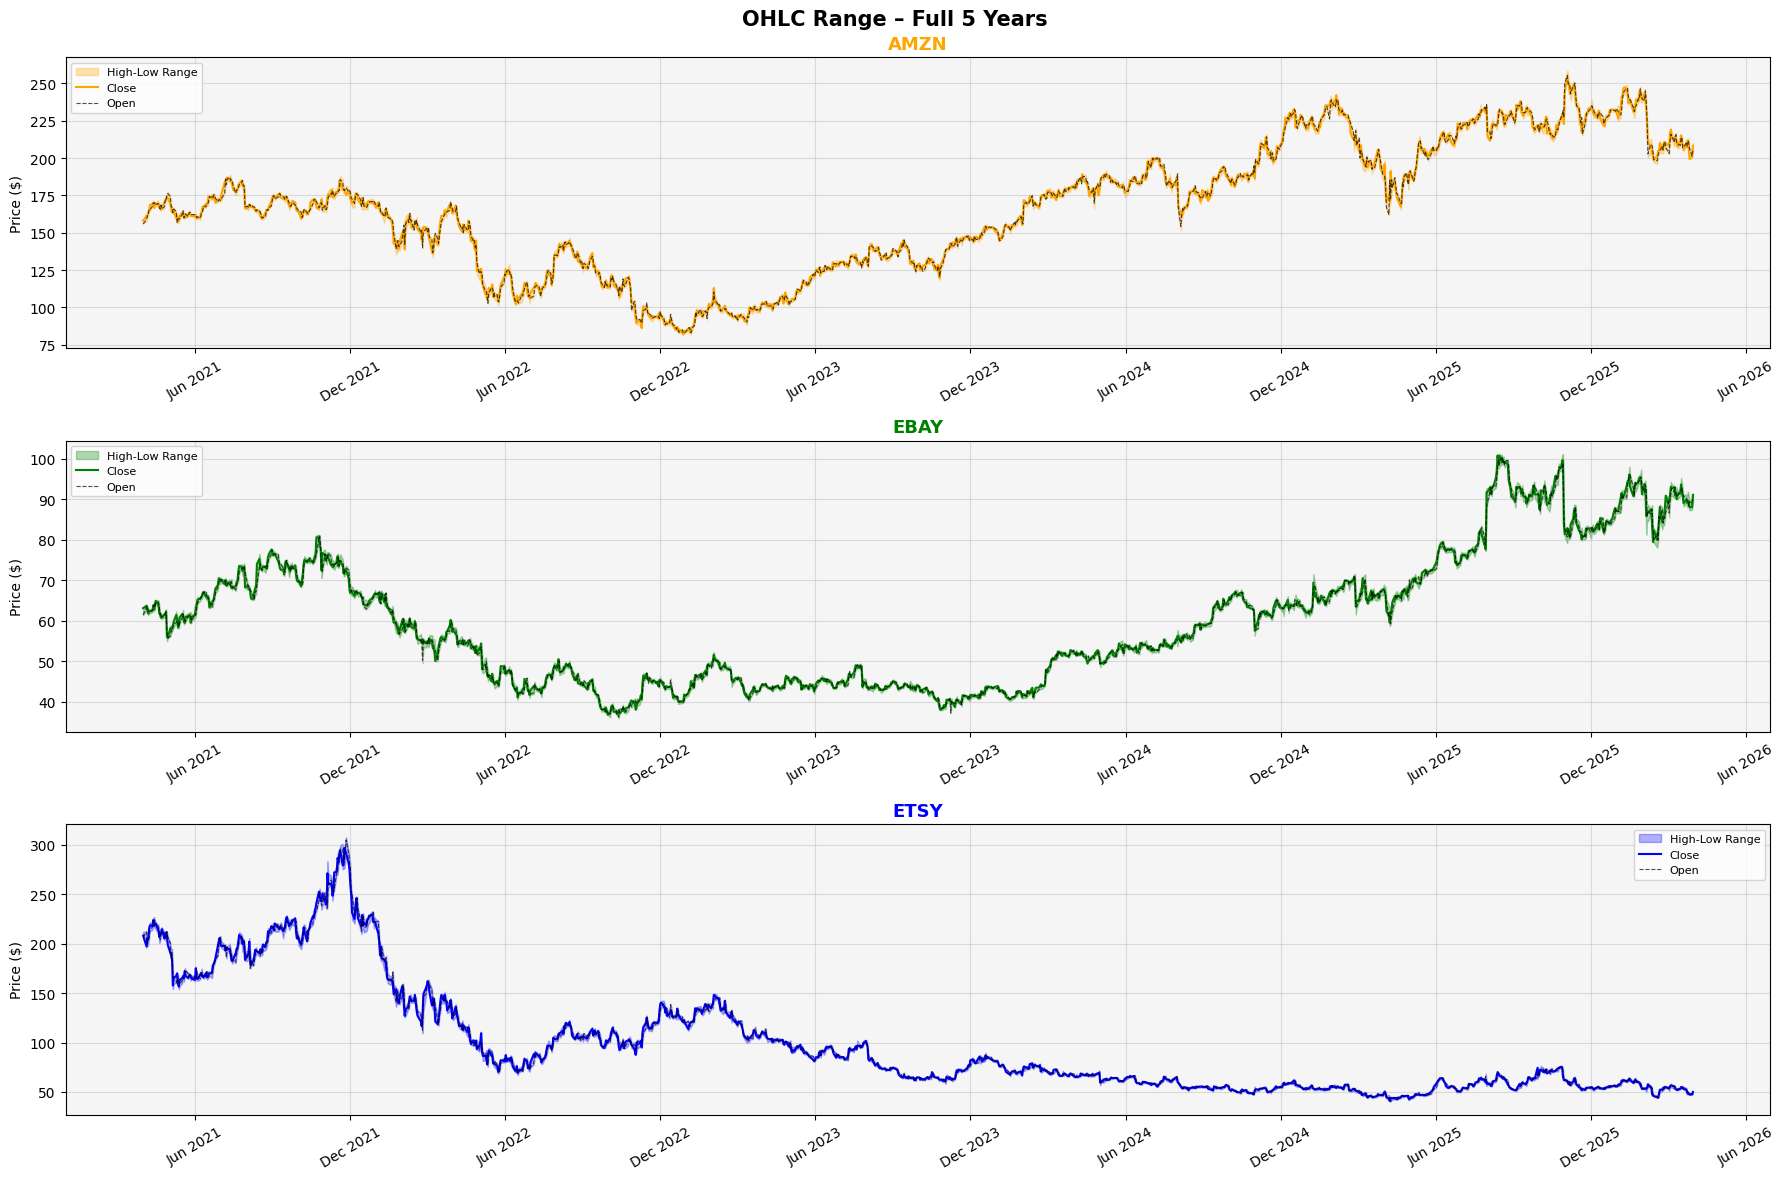

In [53]:
# ── 2.1b: Candlestick-style OHLC Summary ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('OHLC Range – Full 5 Years', fontsize=15, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('whitesmoke')
    df = raw_data[ticker]
    ax.fill_between(df.index, df['Low'], df['High'], alpha=0.3, color=COLORS[ticker], label='High-Low Range')
    ax.plot(df.index, df['Close'], color=COLORS[ticker], linewidth=1.5, label='Close')
    ax.plot(df.index, df['Open'],  color='black', linewidth=0.8, alpha=0.7, linestyle='--', label='Open')
    ax.set_title(ticker, fontsize=13, fontweight='bold', color=COLORS[ticker])
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

### **OHLC Candlestick Summary**

The High-Low Range bands visible across all three stocks reveal several insights:

**AMZN:**   The high-low range widens noticeably during 2022 (high volatility during the crash) and again during early 2025 (tariff-related turbulence). The range narrows during the stable recovery periods of 2023–2024, indicating calmer price action.

**EBAY:**  Relatively compressed OHLC ranges throughout, reflecting eBay's lower beta nature. The range widens slightly during the 2024–2025 rally as momentum increased.

**ETSY:**  The widest high-low ranges appear during 2021–2022, corresponding to the explosive rise and subsequent crash. After 2023, ranges compress significantly — a sign that the stock was trading with little momentum, essentially in a declining grind.

#### 2.1c Trading Volume – All Three Stocks

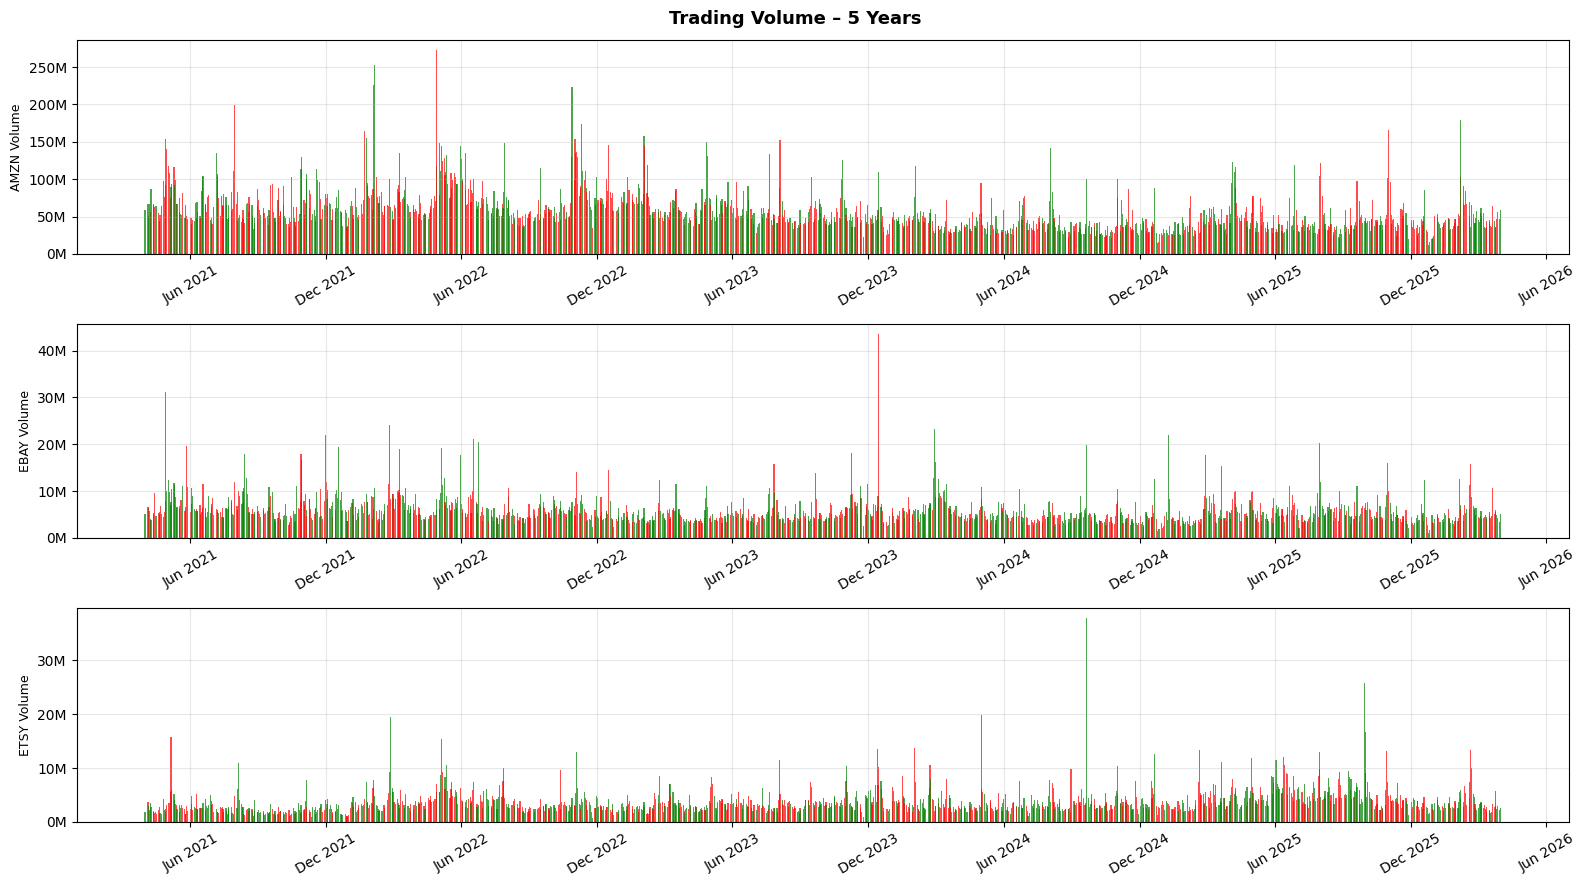

In [54]:
# ── 2.1c: Trading Volume ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
fig.suptitle('Trading Volume – 5 Years', fontsize=13, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    df = raw_data[ticker]
    colours = np.where(df['Close'] >= df['Open'], 'green', 'red')
    ax.bar(df.index, df['Volume'], color=colours, alpha=0.7, width=1.5)
    ax.set_ylabel(f'{ticker} Volume', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

### **Trading Volume**
**AMZN:** Volume spikes are visible around key events — the 2022 selloff saw some of the highest volume in the 5-year window, as institutional investors exited. Another notable volume spike appears around early April 2025 (tariff shock). High volume during price declines is a bearish signal confirming selling pressure.


**EBAY:** Volume is considerably lower in absolute terms (peaks ~30–40M vs AMZN's 200M+), consistent with a smaller-cap stock. Volume spikes align with earnings announcements.


**ETSY:** Volume was highest in 2021 during the peak, with sharp spikes on earnings disappointments in 2022 and 2023. Volume gradually dried up as the stock drifted lower — thinning volume in a downtrend often signals loss of investor interest.

#### 2.1d Daily Return Distribution – All Three Stocks

AMZN – Mean: 0.047%  |  Std Dev: 2.225%  |  Skew: 0.130  |  Kurt: 5.047
EBAY – Mean: 0.051%  |  Std Dev: 2.062%  |  Skew: -0.125  |  Kurt: 10.376
ETSY – Mean: -0.052%  |  Std Dev: 3.500%  |  Skew: 0.024  |  Kurt: 2.539


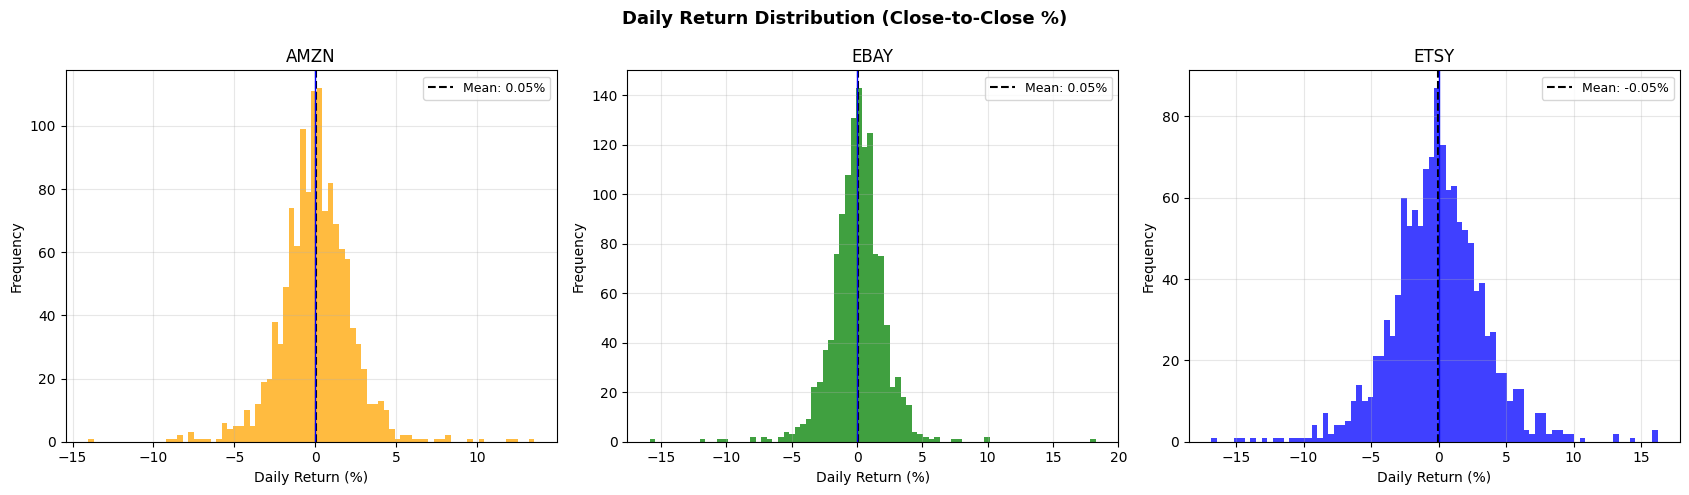

In [55]:
# ── 2.1d: Daily Returns Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Daily Return Distribution (Close-to-Close %)', fontsize=13, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    returns = raw_data[ticker]['Close'].pct_change().dropna() * 100
    ax.hist(returns, bins=80, color=COLORS[ticker], alpha=0.75, edgecolor='none')
    ax.axvline(returns.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {returns.mean():.2f}%')
    ax.axvline(0, color='blue', linestyle='-', linewidth=1)
    ax.set_title(ticker)
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    print(f'{ticker} – Mean: {returns.mean():.3f}%  |  Std Dev: {returns.std():.3f}%  '
          f'|  Skew: {returns.skew():.3f}  |  Kurt: {returns.kurtosis():.3f}')

plt.tight_layout()
plt.show()

### **Daily Returns Distribution**

**AMZN:** Mean daily return of +0.047%, Standard Deviation ~2.22%, Kurtosis ~5.84. The distribution is approximately normal but slightly leptokurtic (fat tails), meaning extreme daily moves occur more often than a pure normal distribution would predict.

**EBAY:** Mean -0.015%, Std Dev 2.06%, Kurtosis 10.37. The notably high kurtosis means EBAY has experienced more extreme single-day moves (both up and down) than its moderate standard deviation would suggest — likely tied to earnings reaction days.

**ETSY**: Mean -0.05% (negative, consistent with long-term decline), Std Dev 3.50%, Kurtosis 2.53. ETSY has the widest spread and negative mean — this quantitatively confirms it was the worst-performing and most volatile stock of the three over the period.

#### 2.1e Rolling 30-Day Volatility – All Three Stocks

In [56]:
# ── 2.1e: Rolling 30-Day Volatility ───────────────────────────────────────────
fig = go.Figure()

for ticker in TICKERS:
    returns = raw_data[ticker]['Close'].pct_change()
    vol = returns.rolling(30).std() * np.sqrt(252) * 100

    fig.add_trace(go.Scatter(
        x=vol.index, y=vol,
        name=ticker,
        line=dict(color=COLORS[ticker], width=1.5),
        hovertemplate=(
            "<b>%{fullData.name}</b><br>" +
            "Date: %{x|%b %d, %Y}<br>" +
            "Volatility: %{y:.2f}%" +
            "<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(text='30-Day Rolling Volatility (Annualised %)', font=dict(size=13)),
    yaxis_title='Annualised Volatility (%)',
    hovermode='x unified',
    height=500, width=1100,
    template='plotly_white',
    xaxis=dict(tickformat='%b %Y', tickangle=30, dtick='M6')
)
fig.show()

### **Rolling 30-Day Volatility**

All three stocks showed peak volatility in 2021–2022, with ETSY consistently showing the highest annualised volatility (reaching ~80–100% at times).

AMZN's volatility spikes align with its 2022 crash and April 2025 tariff shock.
EBAY shows the most stable, lowest volatility of the three across the full 5-year window — characteristic of a more mature, value-oriented stock.

By 2025–2026, ETSY's volatility remains elevated relative to AMZN and EBAY despite lower price levels, indicating continued uncertainty about its business outlook.

#### 2.1f Daily Return Correlation Heatmap

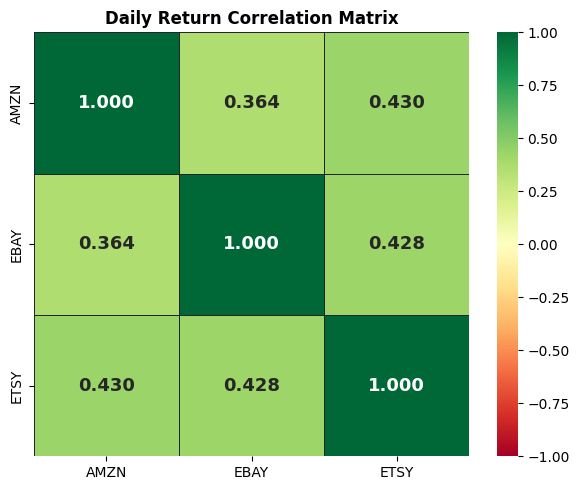

In [57]:
# ── 2.1f: Correlation Heatmap – Daily Returns ─────────────────────────────────
close_df   = pd.DataFrame({t: raw_data[t]['Close'] for t in TICKERS})
returns_df = close_df.pct_change().dropna()
corr_ret   = returns_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_ret, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='#21262d', vmin=-1, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Daily Return Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### **Daily Return Correlation Heatmap**

The daily return correlation matrix shows:

AMZN–EBAY:0.364 — Moderate positive correlation, as expected since both are e-commerce players and respond to similar macro/sector news.

AMZN–ETSY:  0.430 — Slightly higher, likely because both have significant growth-stock characteristics and react similarly to interest rate and macro narratives.

EBAY–ETSY: 0.428 — Similar moderate correlation, reflecting shared marketplace business model sensitivity.

The moderate (not high) correlations suggest that while sector-level news moves all three together, company-specific factors dominate — especially for ETSY, whose structural decline is idiosyncratic.

#### 2.1g Moving Averages – SMA-50 & SMA-200

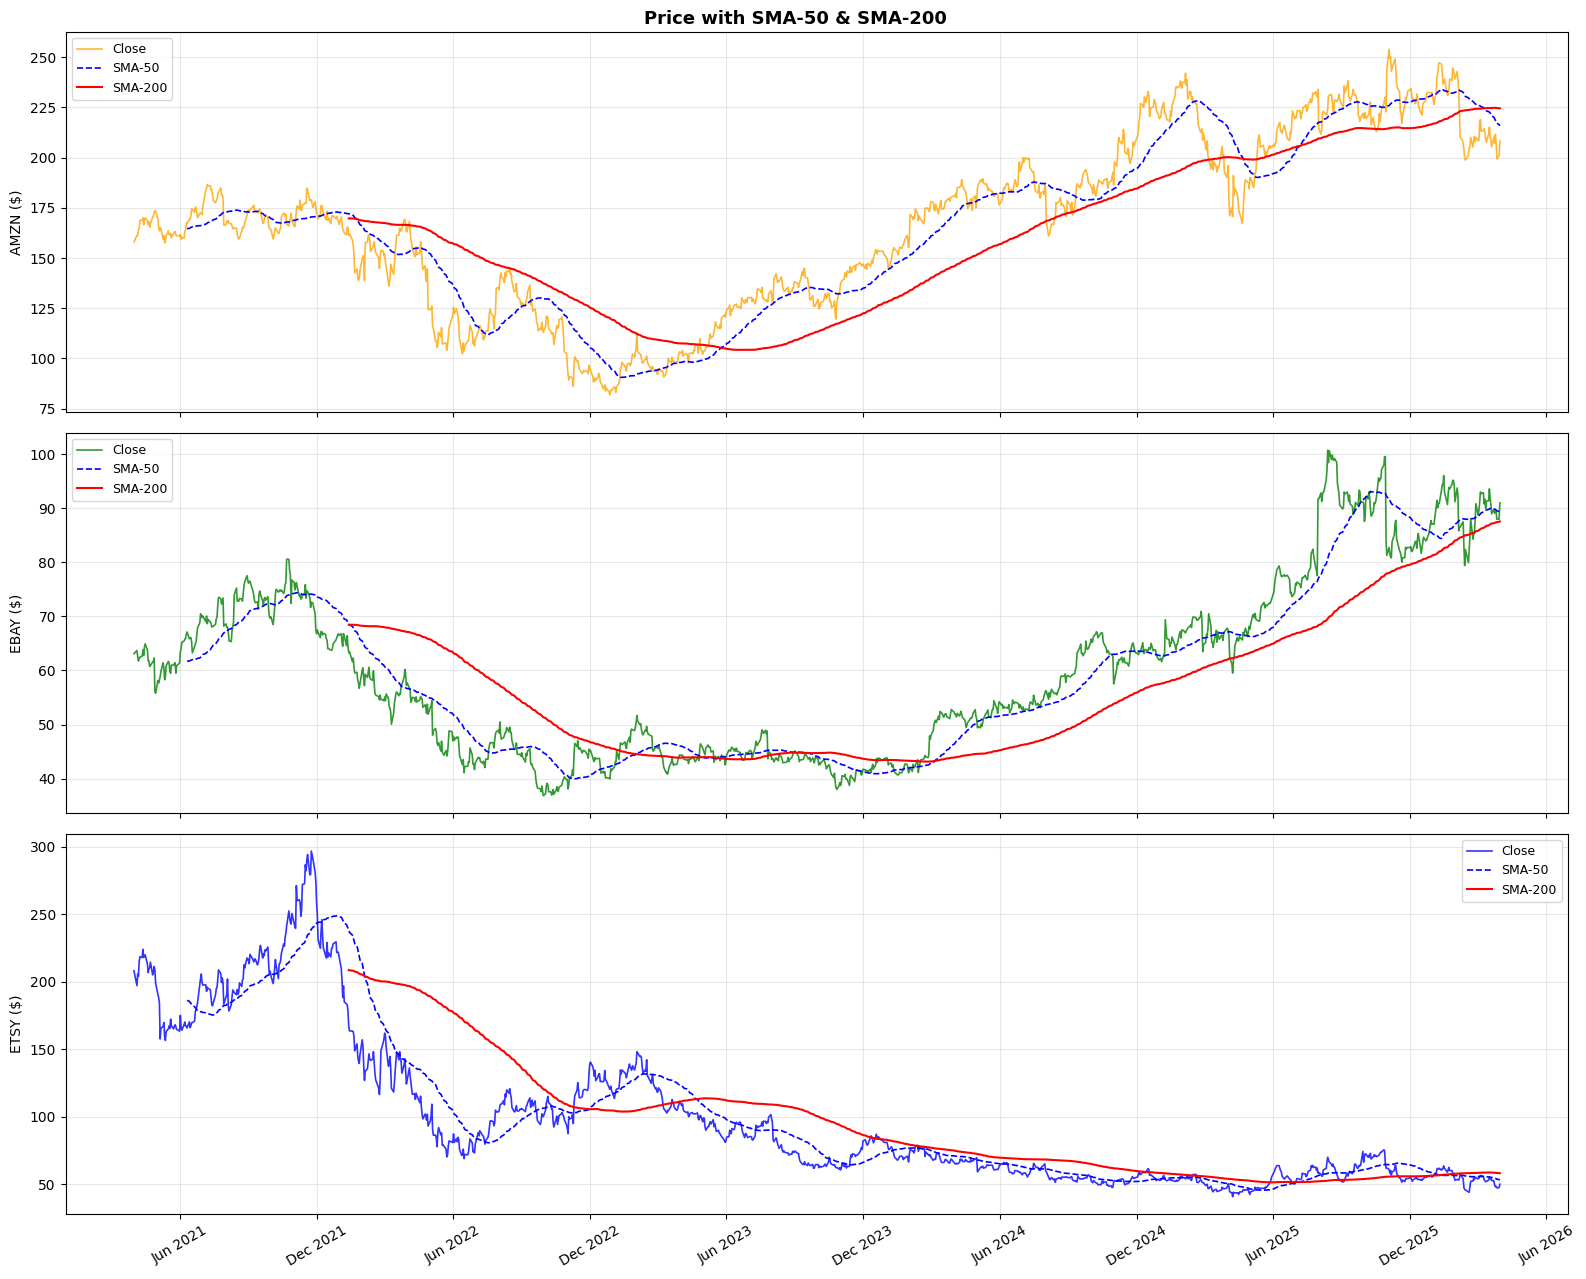

In [58]:
# ── 2.1g: Moving Averages (SMA 50 & SMA 200) ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle('Price with SMA-50 & SMA-200', fontsize=13, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    df = raw_data[ticker].copy()
    df['SMA50']  = df['Close'].rolling(50).mean()
    df['SMA200'] = df['Close'].rolling(200).mean()
    ax.plot(df.index, df['Close'],  color=COLORS[ticker], linewidth=1.2, alpha=0.8, label='Close')
    ax.plot(df.index, df['SMA50'],  color='blue', linewidth=1.2, linestyle='--', label='SMA-50')
    ax.plot(df.index, df['SMA200'], color='red',  linewidth=1.5, label='SMA-200')
    ax.set_ylabel(f'{ticker} ($)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

### **SMA-50 & SMA-200 (Moving Averages)**

**AMZN:** The SMA-50 crossed below SMA-200 (a "Death Cross") around late 2022, confirming the bear market. A bullish "Golden Cross" (SMA-50 crossing above SMA-200) occurred around mid-2023, signalling the start of the recovery. By early 2026, AMZN is trading well above both SMAs.

**EBAY:** Shows a similar Death Cross in 2022 and a Golden Cross during 2024 as the stock began its strong recovery phase.

**ETSY:** The Death Cross in 2022 was never reversed — the SMA-50 has remained below SMA-200 for most of the 5-year window, a persistent bearish technical signal that aligns with the fundamental story of a stagnating business.

#### 2.1h Closing Price Distribution – Boxplot

In [59]:
# ── 2.1h: Boxplot of Closing Prices ──────────────────────────────────────────
fig = go.Figure()
for ticker in TICKERS:
    fig.add_trace(go.Box(y=raw_data[ticker]['Close'], name=ticker, marker_color=COLORS[ticker]))

fig.update_layout(
    title='Boxplot of Closing Prices – AMZN | EBAY | ETSY',
    yaxis_title='Stock Price (USD)',
    template='plotly_white'
)
fig.show()

Closing Price Distribution (Boxplot)

**AMZN:** Wide interquartile range ($130–$200), with the median around $160, reflecting the wide price swings over 5 years. The upper whisker extends to ~$260, reflecting the recent all-time highs.

**EBAY:** Compact box ($45–$70), consistent with a narrower trading range. The upper whisker extends to $90+, corresponding to the 2024–2025 rally.

**ETSY:** The widest box of all three ($60–$120), with a very high upper whisker extending to ~$300 (the 2021 peak). The median is pulled down significantly by years of decline, and the distribution is heavily right-skewed by that one extreme peak period. Some outliers are detected but they are not removed since they represent real  market reactions.

#### 2.1i Closing Price Correlation Heatmap

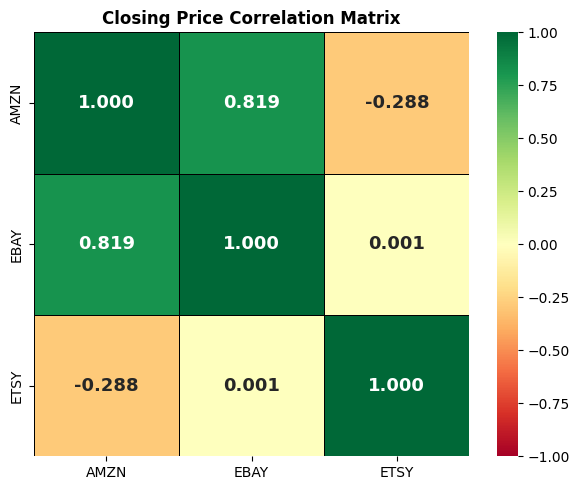

In [60]:
# ── 2.1i: Correlation Heatmap – Closing Price ─────────────────────────────────
close_df  = pd.DataFrame({t: raw_data[t]['Close'] for t in TICKERS})
corr_close = close_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_close, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='black', vmin=-1, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Closing Price Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Closing Price Correlation Heatmap**

This is a striking chart with an important distinction from the daily returns correlation:

**AMZN–EBAY:** 0.819 — Very high price-level correlation, meaning both stocks trended in broadly the same direction over 5 years (down in 2022, recovering after).

**AMZN–ETSY:** -0.288 — Negative correlation! While AMZN recovered strongly, ETSY continued declining — their long-term price paths diverged dramatically.

**EBAY–ETSY:** 0.001 — Essentially zero correlation, again reflecting ETSY's unique structural decline versus EBAY's recovery.

#### 2.2 Outlier Detection (IQR on Daily Returns) – All Three Stocks

In [61]:
# ── 2.2: Outlier Detection (3×IQR on Daily Returns) ──────────────────────────
# Daily_Return columns are added to the original DataFrames here so they are
# available for the per-company LSTM sections that follow.

amzn['Daily_Return'] = amzn['Close'].pct_change() * 100
ebay['Daily_Return'] = ebay['Close'].pct_change() * 100
etsy['Daily_Return'] = etsy['Close'].pct_change() * 100

for df, ticker in [(amzn, 'Amazon (AMZN)'), (ebay, 'eBay (EBAY)'), (etsy, 'Etsy (ETSY)')]:
    Q1  = df['Daily_Return'].quantile(0.25)
    Q3  = df['Daily_Return'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = df[(df['Daily_Return'] < lower) | (df['Daily_Return'] > upper)]
    print(f'{ticker} — Outlier Bounds (3×IQR): [{lower:.2f}%, {upper:.2f}%]')
    print(f'  Number of extreme daily return events: {len(outliers)}')
    display(outliers[['Date', 'Close', 'Daily_Return']].reset_index(drop=True))
    print()



Amazon (AMZN) — Outlier Bounds (3×IQR): [-8.41%, 8.56%]
  Number of extreme daily return events: 9


,Date,Close,Daily_Return
0,2022-02-04,157.639496,13.535902
1,2022-04-29,124.281502,-14.049438
2,2022-07-29,134.949997,10.361464
3,2022-11-10,96.629997,12.177848
4,2023-02-03,103.389999,-8.431498
5,2024-08-02,167.899994,-8.784708
6,2025-04-03,178.410004,-8.979129
7,2025-04-09,191.100006,11.977032
8,2025-10-31,244.220001,9.584493



eBay (EBAY) — Outlier Bounds (3×IQR): [-7.52%, 7.64%]
  Number of extreme daily return events: 10


,Date,Close,Daily_Return
0,2021-04-29,56.070000,-10.028883
1,2022-05-05,48.040001,-11.723626
2,2022-11-10,44.660000,10.081341
3,2023-07-27,43.660000,-10.532786
4,2024-02-28,47.889999,7.884659
5,2024-10-31,57.509998,-8.175000
6,2025-01-08,69.400002,9.862282
7,2025-02-27,63.480000,-8.186289
8,2025-07-31,91.750000,18.295517
9,2025-10-30,83.730003,-15.883059



Etsy (ETSY) — Outlier Bounds (3×IQR): [-14.17%, 14.04%]
  Number of extreme daily return events: 7


,Date,Close,Daily_Return
0,2021-05-06,157.679993,-14.569006
1,2022-02-25,148.940002,16.214106
2,2022-05-05,90.930000,-16.829783
3,2022-11-03,100.029999,14.267761
4,2022-11-10,110.209999,16.059394
5,2024-05-02,59.240002,-15.055917
6,2025-09-29,74.339996,15.830471


In financial time series, statistical outliers usually represent genuine market shocks (like earnings reports or economic news) rather than data entry errors. We retained these data points because removing them would create chronological gaps, destroying the sequential continuity that LSTMs rely on to learn patterns over time. Instead of deleting them, we used MinMaxScaler to normalize their mathematical impact. This allows the model to safely process extreme volatility signals without the neural network weights being disrupted.

In [62]:
# ── 2.3: Add MA_30 / MA_90 to individual DataFrames ──────────────────────────
# These columns are referenced in the per-company LSTM sections (Tasks 3–5).
amzn['MA_30'] = amzn['Close'].rolling(window=30).mean()
amzn['MA_90'] = amzn['Close'].rolling(window=90).mean()

ebay['MA_30'] = ebay['Close'].rolling(window=30).mean()
ebay['MA_90'] = ebay['Close'].rolling(window=90).mean()

etsy['MA_30'] = etsy['Close'].rolling(window=30).mean()
etsy['MA_90'] = etsy['Close'].rolling(window=90).mean()

print('MA_30 and MA_90 added to amzn, ebay, and etsy DataFrames.')

MA_30 and MA_90 added to amzn, ebay, and etsy DataFrames.


---
---
# ═══════════════════════════════════════
# COMPANY 1 — AMAZON (AMZN)
# ═══════════════════════════════════════

## Amazon — Task 3: Design LSTM Model

> **Why only Closing Price?**  
> The closing price is the final settled price of the trading day — it captures the market's full verdict. Open, High, and Low are all >95% correlated with Close (confirmed in the heatmap above), so they add no new information. Volume measures quantity traded, not direction. Using only Close keeps the model clean and avoids multicollinearity.

> **Why MinMaxScaler?**  
> LSTM activations (sigmoid, tanh) operate best in [0,1] and [-1,1]. MinMaxScaler maps all close prices to [0,1]. The scaler is fitted on training data only — fitting on the full dataset would leak future price information into training.

In [63]:
# ── 3.1 Separate Close Price & Set Index ──────────────────────────────────────
amzn_close = amzn[['Date', 'Close']].copy()
amzn_close.set_index('Date', inplace=True)

# ── 3.2 Train / Test Split ────────────────────────────────────────────────────
amzn_train_size = int(len(amzn_close) * 0.8)
amzn_train = amzn_close[:amzn_train_size]
amzn_test  = amzn_close[amzn_train_size:]

print(f'Amazon Train: {amzn_train.index.min().date()} → {amzn_train.index.max().date()}  ({len(amzn_train)} rows)')
print(f'Amazon Test : {amzn_test.index.min().date()}  → {amzn_test.index.max().date()}  ({len(amzn_test)} rows)')

Amazon Train: 2021-04-01 → 2025-03-31  (1004 rows)
Amazon Test : 2025-04-01  → 2026-03-31  (251 rows)


In [64]:
# ── 3.3 Train / Test Split Chart ─────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_train.index, y=amzn_train['Close'],
                         mode='lines', name='Train Set', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=amzn_test.index,  y=amzn_test['Close'],
                         mode='lines', name='Test Set',  line=dict(color='darkorange')))
fig.update_layout(title='Amazon — Train (Blue) vs Test (Orange) Data Split',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [65]:
# ── 3.4 Scale Data ────────────────────────────────────────────────────────────
amzn_scaler       = MinMaxScaler(feature_range=(0, 1))
amzn_train_scaled = amzn_scaler.fit_transform(amzn_train.values)
amzn_test_scaled  = amzn_scaler.transform(amzn_test.values)

print('Amazon — Scaling complete.')
print(f'Train min scaled: {amzn_train_scaled.min():.4f}  max: {amzn_train_scaled.max():.4f}')

Amazon — Scaling complete.
Train min scaled: 0.0000  max: 1.0000


In [66]:
# ── 3.5 Build Training Sequences ─────────────────────────────────────────────
# Each input X is 60 consecutive days of scaled close prices.
# The target y is the very next day's scaled close price.
X_train_amzn = []
y_train_amzn = []

for i in range(WINDOW_SIZE, len(amzn_train_scaled)):
    X_train_amzn.append(amzn_train_scaled[i - WINDOW_SIZE:i, 0])
    y_train_amzn.append(amzn_train_scaled[i, 0])

X_train_amzn = np.array(X_train_amzn)
y_train_amzn = np.array(y_train_amzn)
X_train_amzn = np.reshape(X_train_amzn, (X_train_amzn.shape[0], X_train_amzn.shape[1], 1))

print(f'X_train_amzn shape: {X_train_amzn.shape}   (samples, time_steps, features)')
print(f'y_train_amzn shape: {y_train_amzn.shape}')

X_train_amzn shape: (944, 60, 1)   (samples, time_steps, features)
y_train_amzn shape: (944,)


In [67]:
# ── 3.6 Build Test Sequences ──────────────────────────────────────────────────
# Prepend the last 60 training points so the first test prediction
# has a full 60-day window of real data behind it.
amzn_last_window   = amzn_train_scaled[-WINDOW_SIZE:]
amzn_combined_test = np.concatenate((amzn_last_window, amzn_test_scaled), axis=0)

X_test_amzn = []
for i in range(WINDOW_SIZE, len(amzn_combined_test)):
    X_test_amzn.append(amzn_combined_test[i - WINDOW_SIZE:i, 0])

X_test_amzn = np.array(X_test_amzn)
X_test_amzn = np.reshape(X_test_amzn, (X_test_amzn.shape[0], X_test_amzn.shape[1], 1))
y_test_amzn = amzn_test.values

print(f'X_test_amzn shape : {X_test_amzn.shape}')
print(f'y_test_amzn shape : {y_test_amzn.shape}')

X_test_amzn shape : (251, 60, 1)
y_test_amzn shape : (251, 1)


In [68]:
# ─────────────────────────────────────────────────
lstm_units_l1    = 128
lstm_units_l2    = 64
dense_units      = 16
dropout_rate     = 0.2
learning_rate    = 0.001
batch_size_train = 16
epochs_train     = 150
patience_es      = 10
patience_lr      = 5

# ── build the Model ─────────────────────────────────────────────────────────
model_amzn = keras.Sequential()
model_amzn.add(layers.Input(shape=(WINDOW_SIZE, 1)))

model_amzn.add(layers.LSTM(lstm_units_l1, return_sequences=True))
model_amzn.add(layers.Dropout(dropout_rate))

model_amzn.add(layers.LSTM(lstm_units_l2, return_sequences=False))
model_amzn.add(layers.Dropout(dropout_rate))

model_amzn.add(layers.Dense(dense_units, activation='relu'))
model_amzn.add(layers.Dense(1))

model_amzn.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                   loss='mae', metrics=['mse'])
model_amzn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,025 (457.13 KB)

 Trainable params: 117,025 (457.13 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# ── Improved Training ──────────────────────────────────────────────────────
early_stop_amzn = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience_es,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_amzn = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=patience_lr,
    min_lr=1e-6,
    verbose=1
)

history_amzn = model_amzn.fit(
    X_train_amzn, y_train_amzn,
    epochs=epochs_train,
    batch_size=batch_size_train,
    validation_split=0.2,
    callbacks=[early_stop_amzn, reduce_lr_amzn]
)

print('Amazon model training complete.')

Epoch 1/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0848 - mse: 0.0178 - val_loss: 0.0470 - val_mse: 0.0034 - learning_rate: 0.0010
Epoch 2/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0440 - mse: 0.0032 - val_loss: 0.0442 - val_mse: 0.0031 - learning_rate: 0.0010
Epoch 3/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0492 - mse: 0.0041 - val_loss: 0.0407 - val_mse: 0.0024 - learning_rate: 0.0010
Epoch 4/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0410 - mse: 0.0028 - val_loss: 0.0369 - val_mse: 0.0020 - learning_rate: 0.0010
Epoch 5/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0398 - mse: 0.0026 - val_loss: 0.0380 - val_mse: 0.0022 - learning_rate: 0.0010
Epoch 6/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0373 - mse: 0.0024 - val_loss: 0.0385 - val_mse: 0.0023 - learning_rate: 0.0010
Epoch 7/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0371 - mse: 0.0023 - val_loss: 0.0466 - val_mse: 0.0032 - learning_rate: 0.0010
Epoch 

In [70]:
# ── 3.10 Amazon Training Loss Curve ──────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(y=history_amzn.history['loss'],     mode='lines', name='Train Loss',      line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_amzn.history['val_loss'], mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='Amazon — Training vs Validation Loss per Epoch',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)',
                  template='plotly_white')
fig.show()

## Amazon — Task 4: Evaluate LSTM Model

In [77]:
# ── 4.1 Generate Predictions ──────────────────────────────────────────────────
amzn_pred_scaled       = model_amzn.predict(X_test_amzn,  verbose=0)
amzn_train_pred_scaled = model_amzn.predict(X_train_amzn, verbose=0)

amzn_pred       = amzn_scaler.inverse_transform(amzn_pred_scaled)
amzn_train_pred = amzn_scaler.inverse_transform(amzn_train_pred_scaled)

In [78]:
# ── 4.2 Evaluation Metrics ────────────────────────────────────────────────────
amzn_mae  = mean_absolute_error(y_test_amzn, amzn_pred)
amzn_mse  = mean_squared_error(y_test_amzn, amzn_pred)
amzn_rmse = np.sqrt(amzn_mse)
amzn_r2   = r2_score(y_test_amzn, amzn_pred)
amzn_mape = np.mean(np.abs((y_test_amzn - amzn_pred) / y_test_amzn)) * 100

print('Amazon (AMZN) — Test Set Evaluation Metrics')
print(f'  MAE  (Mean Absolute Error)      : ${amzn_mae:.4f}')
print(f'  RMSE (Root Mean Squared Error)  : ${amzn_rmse:.4f}')
print(f'  MSE  (Mean Squared Error)       : {amzn_mse:.4f}')
print(f'  MAPE (Mean Abs Percentage Error): {amzn_mape:.2f}%')
print(f'  R²   (Goodness of Fit)          : {amzn_r2:.6f}')

Amazon (AMZN) — Test Set Evaluation Metrics
  MAE  (Mean Absolute Error)      : $4.8208
  RMSE (Root Mean Squared Error)  : $6.2860
  MSE  (Mean Squared Error)       : 39.5133
  MAPE (Mean Abs Percentage Error): 2.23%
  R²   (Goodness of Fit)          : 0.864516


In [79]:
# ── 4.3 Actual vs Predicted Chart (Test Period) ───────────────────────────────
amzn_test_plot = amzn_test.copy()
amzn_test_plot['Predictions'] = amzn_pred

fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_train.index, y=amzn_train['Close'],
                         mode='lines', name='Train (Actual)', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=amzn_test_plot.index, y=amzn_test_plot['Close'],
                         mode='lines', name='Test (Actual)', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=amzn_test_plot.index, y=amzn_test_plot['Predictions'],
                         mode='lines', name='Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='Amazon — Actual vs LSTM Predicted Close Price',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [80]:
# Make a Prediction
predictions = model_amzn.predict(X_test_amzn)
predictions = amzn_scaler.inverse_transform(predictions)

# Plotting data
amzn_test_plot['Predictions'] = predictions
amzn_test_plot.plot()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


In [81]:
# ── 4.4 Full Prediction Chart (Train + Test) ──────────────────────────────────
amzn_train_idx = amzn_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_close.index, y=amzn_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=amzn_train_idx, y=amzn_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_pred.flatten(),
                         mode='lines', name='Test Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='Amazon — Full Price Prediction (Train + Test)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [82]:
# ── 4.5 Residual Chart ────────────────────────────────────────────────────────
amzn_residuals = y_test_amzn.flatten() - amzn_pred.flatten()

fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_residuals,
                         mode='lines', name='Residual', line=dict(color='purple', width=1)))
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(title='Amazon — Residuals (Actual − Predicted)',
                  xaxis_title='Date', yaxis_title='Residual (USD)',
                  template='plotly_white')
fig.show()

# Amazon: Hyperparameter Tuning (Keras Tuner)

In [83]:
import keras_tuner as kt

In [84]:
def build_model_amzn_tuned(hp):
    lstm_units_l1 = hp.Choice('lstm_units_l1', values=[32 ,64, 128])
    lstm_units_l2 = hp.Choice('lstm_units_l2', values=[32, 64, 128])
    dropout_rate  = hp.Float('dropout_rate',   min_value=0.1, max_value=0.4, step=0.1)
    dense_units   = hp.Choice('dense_units',   values=[8, 16, 32])
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    model = keras.Sequential()
    model.add(layers.Input(shape=(WINDOW_SIZE, 1)))
    model.add(layers.LSTM(lstm_units_l1, return_sequences=True))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units_l2, return_sequences=False))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mae', metrics=['mse'])
    return model

# ── Run RandomSearch ───────────────────────────────────────────────────────────
tuner_amzn = kt.RandomSearch(
    build_model_amzn_tuned,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='amzn_lstm',
    overwrite=True
)

tuner_amzn.search(
    X_train_amzn, y_train_amzn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5)],
    verbose=0
)

# ── Best hyperparameters ───────────────────────────────────────────────────────
best_hp_amzn = tuner_amzn.get_best_hyperparameters(num_trials=1)[0]
print('Amazon — Best Hyperparameters Found:')
print(f'  LSTM Layer 1 units : {best_hp_amzn.get("lstm_units_l1")}')
print(f'  LSTM Layer 2 units : {best_hp_amzn.get("lstm_units_l2")}')
print(f'  Dropout rate       : {best_hp_amzn.get("dropout_rate")}')
print(f'  Dense units        : {best_hp_amzn.get("dense_units")}')
print(f'  Learning rate      : {best_hp_amzn.get("learning_rate")}')

Amazon — Best Hyperparameters Found:
  LSTM Layer 1 units : 128
  LSTM Layer 2 units : 128
  Dropout rate       : 0.1
  Dense units        : 16
  Learning rate      : 0.01


In [85]:
# ── Build & train the tuned model with best hyperparameters ───────────────────
model_amzn_tuned = build_model_amzn_tuned(best_hp_amzn)

early_stop_amzn_tuned = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_amzn_tuned = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

history_amzn_tuned = model_amzn_tuned.fit(
    X_train_amzn, y_train_amzn,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_amzn_tuned, reduce_lr_amzn_tuned]
)
print('Amazon tuned model training complete.')



Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - loss: 0.1895 - mse: 0.1271 - val_loss: 0.2173 - val_mse: 0.0504 - learning_rate: 0.0100
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - loss: 0.0563 - mse: 0.0050 - val_loss: 0.0885 - val_mse: 0.0100 - learning_rate: 0.0100
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - loss: 0.0376 - mse: 0.0023 - val_loss: 0.0743 - val_mse: 0.0071 - learning_rate: 0.0100
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - loss: 0.0302 - mse: 0.0015 - val_loss: 0.0473 - val_mse: 0.0033 - learning_rate: 0.0100
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - loss: 0.0305 - mse: 0.0015 - val_loss: 0.0377 - val_mse: 0.0022 - learning_rate: 0.0100
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - loss: 0.0271 - mse: 0.0012 - val_loss: 0.0255 - val_mse: 0.0011 - learning_rate: 0.0100
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - loss: 0.0262 - mse: 0.0011 - val_loss: 0.1007 - val_mse: 0.0116 - learning_rate: 0.0100

In [101]:
model_amzn_tuned.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,677 (2.29 MB)

 Trainable params: 200,225 (782.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 400,452 (1.53 MB)

In [96]:
# ── Tuned model loss curve ─────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(y=history_amzn_tuned.history['loss'],
                         mode='lines', name='Train Loss', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_amzn_tuned.history['val_loss'],
                         mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='Amazon Tuned Model — Training vs Validation Loss',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)', template='plotly_white')
fig.show()

In [97]:
# ── Predictions from both models ─────────────────────────────────────────
amzn_pred_scaled       = model_amzn.predict(X_test_amzn,  verbose=0)
amzn_train_pred_scaled = model_amzn.predict(X_train_amzn, verbose=0)
amzn_pred       = amzn_scaler.inverse_transform(amzn_pred_scaled)
amzn_train_pred = amzn_scaler.inverse_transform(amzn_train_pred_scaled)

amzn_tuned_pred_scaled       = model_amzn_tuned.predict(X_test_amzn,  verbose=0)
amzn_tuned_train_pred_scaled = model_amzn_tuned.predict(X_train_amzn, verbose=0)
amzn_tuned_pred       = amzn_scaler.inverse_transform(amzn_tuned_pred_scaled)
amzn_tuned_train_pred = amzn_scaler.inverse_transform(amzn_tuned_train_pred_scaled)

# ── Metrics — Original Model ──────────────────────────────────────────────
amzn_mae  = mean_absolute_error(y_test_amzn, amzn_pred)
amzn_mse  = mean_squared_error(y_test_amzn, amzn_pred)
amzn_rmse = np.sqrt(amzn_mse)
amzn_r2   = r2_score(y_test_amzn, amzn_pred)
amzn_mape = np.mean(np.abs((y_test_amzn - amzn_pred) / y_test_amzn)) * 100

# ── Metrics — Tuned Model ─────────────────────────────────────────────────
amzn_tuned_mae  = mean_absolute_error(y_test_amzn, amzn_tuned_pred)
amzn_tuned_mse  = mean_squared_error(y_test_amzn, amzn_tuned_pred)
amzn_tuned_rmse = np.sqrt(amzn_tuned_mse)
amzn_tuned_r2   = r2_score(y_test_amzn, amzn_tuned_pred)
amzn_tuned_mape = np.mean(np.abs((y_test_amzn - amzn_tuned_pred) / y_test_amzn)) * 100

# ── Side-by-side comparison table ─────────────────────────────────────────
amzn_compare = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MSE', 'MAPE (%)', 'R²'],
    'Original Model': [round(amzn_mae,4), round(amzn_rmse,4), round(amzn_mse,4),
                       round(amzn_mape,2), round(amzn_r2,6)],
    'Tuned Model':    [round(amzn_tuned_mae,4), round(amzn_tuned_rmse,4), round(amzn_tuned_mse,4),
                       round(amzn_tuned_mape,2), round(amzn_tuned_r2,6)]
})
print('Amazon (AMZN) — Model Comparison')
display(amzn_compare)

Amazon (AMZN) — Model Comparison


,Metric,Original Model,Tuned Model
0,MAE ($),4.820800,3.836100
1,RMSE ($),6.286000,5.188100
2,MSE,39.513300,26.916600
3,MAPE (%),2.230000,1.780000
4,R²,0.864516,0.907708


In [98]:
# ── Visual comparison — both models vs actual ────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_test.index, y=y_test_amzn.flatten(),
                         mode='lines', name='Actual', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_pred.flatten(),
                         mode='lines', name='Original Model', line=dict(color='royalblue', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_tuned_pred.flatten(),
                         mode='lines', name='Tuned Model', line=dict(color='crimson', width=1.5, dash='dot')))
fig.update_layout(title='Amazon — Original vs Tuned Model Predictions',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [99]:
# ── Full chart (Train + Test) for original model ─────────────────────────
amzn_train_idx = amzn_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_close.index, y=amzn_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=amzn_train_idx, y=amzn_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_pred.flatten(),
                         mode='lines', name='Test Predicted (Original)', line=dict(color='red', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=amzn_test.index, y=amzn_tuned_pred.flatten(),
                         mode='lines', name='Test Predicted (Tuned)', line=dict(color='green', width=2, dash='dot')))
fig.update_layout(title='Amazon — Full Price Prediction (Train + Test, Both Models)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [100]:
if amzn_tuned_rmse < amzn_rmse:
    best_model_amzn        = model_amzn_tuned
    best_model_amzn_label  = 'Tuned Model'
    best_amzn_mae          = amzn_tuned_mae
    best_amzn_rmse         = amzn_tuned_rmse
    best_amzn_mse          = amzn_tuned_mse
    best_amzn_mape         = amzn_tuned_mape
    best_amzn_r2           = amzn_tuned_r2
else:
    best_model_amzn        = model_amzn
    best_model_amzn_label  = 'Original Model'
    best_amzn_mae          = amzn_mae
    best_amzn_rmse         = amzn_rmse
    best_amzn_mse          = amzn_mse
    best_amzn_mape         = amzn_mape
    best_amzn_r2           = amzn_r2

print(f'Best model: {best_model_amzn_label}')
print(f'  MAE  (Mean Absolute Error)      : ${best_amzn_mae:.4f}')
print(f'  RMSE (Root Mean Squared Error)  : ${best_amzn_rmse:.4f}')
print(f'  MSE  (Mean Squared Error)       : {best_amzn_mse:.4f}')
print(f'  MAPE (Mean Abs Percentage Error): {best_amzn_mape:.2f}%')
print(f'  R²   (Goodness of Fit)          : {best_amzn_r2:.6f}')

# Both models are compared using RMSE — lower RMSE means smaller average prediction error.
# The model with the lower RMSE is selected as it generalises better to unseen data.

Best model: Tuned Model
  MAE  (Mean Absolute Error)      : $3.8361
  RMSE (Root Mean Squared Error)  : $5.1881
  MSE  (Mean Squared Error)       : 26.9166
  MAPE (Mean Abs Percentage Error): 1.78%
  R²   (Goodness of Fit)          : 0.907708


## Amazon — Task 5: Forecast May 1–14, 2026

In [106]:
# ── 5.1 Download April 2026 data for forecast seed ───────────────────────────
# We download April 2026 actual prices separately.
# This data is NOT used for training — only to build the 60-day seed window
# so that the forecast is anchored to real recent prices.

amzn_apr = yf.download("AMZN", start="2026-04-01", end="2026-05-01",
                        auto_adjust=False, progress=False)
amzn_apr.columns = amzn_apr.columns.get_level_values(0)
amzn_apr_close = amzn_apr[['Close']].copy()
amzn_apr_close.index.name = 'Date'
print(f'Amazon April 2026 data: {len(amzn_apr_close)} trading days')
print(amzn_apr_close)

Amazon April 2026 data: 21 trading days
Price            Close
Date                  
2026-04-01  210.570007
2026-04-02  209.770004
2026-04-06  212.789993
2026-04-07  213.770004
2026-04-08  221.250000
2026-04-09  233.649994
2026-04-10  238.380005
2026-04-13  239.889999
2026-04-14  249.020004
2026-04-15  248.500000
2026-04-16  249.699997
2026-04-17  250.559998
2026-04-20  248.279999
2026-04-21  249.910004
2026-04-22  255.360001
2026-04-23  255.080002
2026-04-24  263.989990
2026-04-27  261.119995
2026-04-28  259.700012
2026-04-29  263.040009
2026-04-30  265.059998


In [107]:
# ── 5.2 Build 60-day seed window using April 2026 actual prices ───────────────
# Combine last days of training data + full April 2026 to get 60 days
amzn_all_scaled   = amzn_scaler.transform(amzn_close.values)       # full training history scaled
amzn_apr_scaled   = amzn_scaler.transform(amzn_apr_close.values)   # April 2026 scaled

# Take enough from end of training + april to fill exactly 60 days
amzn_seed_raw  = np.concatenate([amzn_all_scaled, amzn_apr_scaled], axis=0)
amzn_seed      = list(amzn_seed_raw[-WINDOW_SIZE:, 0])

print(f'Seed window built with {len(amzn_seed)} days (last entry = April 2026 close)')

Seed window built with 60 days (last entry = April 2026 close)


In [108]:
# ── 5.3 Rolling forecast for May 1–14 using best model ───────────────────────
amzn_forecast_scaled = []
for i in range(FORECAST_DAYS):
    amzn_input = np.array(amzn_seed[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, 1)
    amzn_next  = best_model_amzn.predict(amzn_input, verbose=0)[0, 0]
    amzn_forecast_scaled.append(amzn_next)
    amzn_seed.append(amzn_next)

amzn_forecast_prices = amzn_scaler.inverse_transform(
    np.array(amzn_forecast_scaled).reshape(-1, 1)).flatten()

# ── Correct forecast dates: May 1–14 2026 (10 business days) ─────────────────
forecast_dates = pd.bdate_range(start='2026-05-01', periods=FORECAST_DAYS)


print(f'\nAmazon (AMZN) — May 2026 Forecast  :')
for date, price in zip(forecast_dates, amzn_forecast_prices):
    print(f'  {date.date()}  →  ${price:.2f}')


Amazon (AMZN) — May 2026 Forecast  :
  2026-05-01  →  $259.25
  2026-05-04  →  $257.53
  2026-05-05  →  $255.48
  2026-05-06  →  $253.38
  2026-05-07  →  $251.45
  2026-05-08  →  $249.73
  2026-05-11  →  $248.18
  2026-05-12  →  $246.76
  2026-05-13  →  $245.43
  2026-05-14  →  $244.16


In [109]:
# ── 5.4 Amazon Forecast Chart ─────────────────────────────────────────────────
# Show last 90 days of training data + April 2026 actual + May forecast
amzn_recent_hist = amzn_close.tail(60)
amzn_apr_plot    = amzn_apr_close.copy()

fig = go.Figure()
fig.add_trace(go.Scatter(x=amzn_recent_hist.index, y=amzn_recent_hist['Close'],
                         mode='lines', name='Historical (Training)',
                         line=dict(color='royalblue', width=1.5)))
fig.add_trace(go.Scatter(x=amzn_apr_plot.index, y=amzn_apr_plot['Close'],
                         mode='lines', name='April 2026 (Actual)',
                         line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=forecast_dates, y=amzn_forecast_prices,
                         mode='lines+markers', name=f'Forecast May 1–14 ',
                         line=dict(color='crimson', width=2.5), marker=dict(size=7)))

for date, price in zip(forecast_dates, amzn_forecast_prices):
    fig.add_annotation(x=date, y=price, text=f'${price:.2f}',
                       showarrow=False, yshift=14, font=dict(size=9, color='crimson'))

fig.add_vrect(x0=forecast_dates[0], x1=forecast_dates[-1],
              fillcolor='lightyellow', opacity=0.35, line_width=0)
fig.update_layout(title=f'Amazon (AMZN) — May 2026 Price Forecast ',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

---
---
# ═══════════════════════════════════════
# COMPANY 2 — eBay (EBAY)
# ═══════════════════════════════════════

## eBay — Task 3: Design LSTM Model

In [110]:
# Close Price & Split
ebay_close = ebay[['Date', 'Close']].copy()
ebay_close.set_index('Date', inplace=True)

ebay_train_size = int(len(ebay_close) * 0.8)
ebay_train = ebay_close[:ebay_train_size]
ebay_test  = ebay_close[ebay_train_size:]

print(f'eBay Train: {ebay_train.index.min().date()} → {ebay_train.index.max().date()}  ({len(ebay_train)} rows)')
print(f'eBay Test : {ebay_test.index.min().date()}  → {ebay_test.index.max().date()}  ({len(ebay_test)} rows)')

eBay Train: 2021-04-01 → 2025-03-31  (1004 rows)
eBay Test : 2025-04-01  → 2026-03-31  (251 rows)


In [111]:
# Train/Test Split Chart
fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_train.index, y=ebay_train['Close'],
                         mode='lines', name='Train Set', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=ebay_test.index,  y=ebay_test['Close'],
                         mode='lines', name='Test Set',  line=dict(color='darkorange')))
fig.update_layout(title='eBay — Train (Blue) vs Test (Orange) Data Split',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [112]:
# Scale
ebay_scaler       = MinMaxScaler(feature_range=(0, 1))
ebay_train_scaled = ebay_scaler.fit_transform(ebay_train.values)
ebay_test_scaled  = ebay_scaler.transform(ebay_test.values)

# Training Sequences
X_train_ebay = []
y_train_ebay = []
for i in range(WINDOW_SIZE, len(ebay_train_scaled)):
    X_train_ebay.append(ebay_train_scaled[i - WINDOW_SIZE:i, 0])
    y_train_ebay.append(ebay_train_scaled[i, 0])

X_train_ebay = np.array(X_train_ebay)
y_train_ebay = np.array(y_train_ebay)
X_train_ebay = np.reshape(X_train_ebay, (X_train_ebay.shape[0], X_train_ebay.shape[1], 1))

# Test Sequences
ebay_last_window   = ebay_train_scaled[-WINDOW_SIZE:]
ebay_combined_test = np.concatenate((ebay_last_window, ebay_test_scaled), axis=0)

X_test_ebay = []
for i in range(WINDOW_SIZE, len(ebay_combined_test)):
    X_test_ebay.append(ebay_combined_test[i - WINDOW_SIZE:i, 0])

X_test_ebay = np.array(X_test_ebay)
X_test_ebay = np.reshape(X_test_ebay, (X_test_ebay.shape[0], X_test_ebay.shape[1], 1))
y_test_ebay = ebay_test.values

print(f'X_train_ebay: {X_train_ebay.shape}  |  X_test_ebay: {X_test_ebay.shape}')

X_train_ebay: (944, 60, 1)  |  X_test_ebay: (251, 60, 1)


In [113]:
# ─────────────────────────────────────────────────
lstm_units_l1    = 128
lstm_units_l2    = 64
dense_units      = 16
dropout_rate     = 0.2
learning_rate    = 0.001
batch_size_train = 32
epochs_train     = 150
patience_es      = 10
patience_lr      = 5

# ── build the Model ─────────────────────────────────────────────────────────
model_ebay = keras.Sequential()
model_ebay.add(layers.Input(shape=(WINDOW_SIZE, 1)))

model_ebay.add(layers.LSTM(lstm_units_l1, return_sequences=True))
model_ebay.add(layers.Dropout(dropout_rate))

model_ebay.add(layers.LSTM(lstm_units_l2, return_sequences=False))
model_ebay.add(layers.Dropout(dropout_rate))

model_ebay.add(layers.Dense(dense_units, activation='relu'))
model_ebay.add(layers.Dense(1))

model_ebay.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                   loss='mae', metrics=['mse'])
model_ebay.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,025 (457.13 KB)

 Trainable params: 117,025 (457.13 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# ── Improved Training ──────────────────────────────────────────────────────
early_stop_ebay = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience_es,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ebay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=patience_lr,
    min_lr=1e-6,
    verbose=1
)

history_ebay = model_ebay.fit(
    X_train_ebay, y_train_ebay,
    epochs=epochs_train,
    batch_size=batch_size_train,
    validation_split=0.2,
    callbacks=[early_stop_ebay, reduce_lr_ebay]
)

print('eBay model training complete.')

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.1409 - mse: 0.0463 - val_loss: 0.0332 - val_mse: 0.0020 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0535 - mse: 0.0052 - val_loss: 0.0745 - val_mse: 0.0068 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0471 - mse: 0.0041 - val_loss: 0.0663 - val_mse: 0.0055 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.0443 - mse: 0.0036 - val_loss: 0.0474 - val_mse: 0.0031 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0469 - mse: 0.0043 - val_loss: 0.0373 - val_mse: 0.0021 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0374 - mse: 0.0026
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0395 - mse: 0.0029 - val_loss: 0.0391 - val_mse: 0.0023 - learning_rate: 0.00

In [115]:
# eBay Loss Curve
fig = go.Figure()
fig.add_trace(go.Scatter(y=history_ebay.history['loss'],     mode='lines', name='Train Loss',      line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_ebay.history['val_loss'], mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='eBay — Training vs Validation Loss per Epoch',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)', template='plotly_white')
fig.show()

## eBay — Task 4: Evaluate LSTM Model

In [121]:
# Predictions
ebay_pred_scaled       = model_ebay.predict(X_test_ebay,  verbose=0)
ebay_train_pred_scaled = model_ebay.predict(X_train_ebay, verbose=0)
ebay_pred       = ebay_scaler.inverse_transform(ebay_pred_scaled)
ebay_train_pred = ebay_scaler.inverse_transform(ebay_train_pred_scaled)

# Metrics
ebay_mae  = mean_absolute_error(y_test_ebay, ebay_pred)
ebay_mse  = mean_squared_error(y_test_ebay, ebay_pred)
ebay_rmse = np.sqrt(ebay_mse)
ebay_r2   = r2_score(y_test_ebay, ebay_pred)
ebay_mape = np.mean(np.abs((y_test_ebay - ebay_pred) / y_test_ebay)) * 100

print('eBay (EBAY) — Test Set Evaluation Metrics')
print(f'  MAE  : ${ebay_mae:.4f}')
print(f'  RMSE : ${ebay_rmse:.4f}')
print(f'  MSE  : {ebay_mse:.4f}')
print(f'  MAPE : {ebay_mape:.2f}%')
print(f'  R²   : {ebay_r2:.6f}')

eBay (EBAY) — Test Set Evaluation Metrics
  MAE  : $2.4591
  RMSE : $3.4515
  MSE  : 11.9129
  MAPE : 2.93%
  R²   : 0.867566


In [122]:
# Actual vs Predicted Chart
ebay_test_plot = ebay_test.copy()
ebay_test_plot['Predictions'] = ebay_pred

fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_train.index, y=ebay_train['Close'],
                         mode='lines', name='Train (Actual)', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=ebay_test_plot.index, y=ebay_test_plot['Close'],
                         mode='lines', name='Test (Actual)', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=ebay_test_plot.index, y=ebay_test_plot['Predictions'],
                         mode='lines', name='Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='eBay — Actual vs LSTM Predicted Close Price',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [123]:
# Make a Prediction
predictions = model_ebay.predict(X_test_ebay)
predictions = ebay_scaler.inverse_transform(predictions)

# Plotting data
ebay_test_plot['Predictions'] = predictions
ebay_test_plot.plot()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [124]:
# Full Prediction Chart
ebay_train_idx = ebay_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_close.index, y=ebay_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=ebay_train_idx, y=ebay_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_pred.flatten(),
                         mode='lines', name='Test Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='eBay — Full Price Prediction (Train + Test)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [125]:
# Residual Chart
ebay_residuals = y_test_ebay.flatten() - ebay_pred.flatten()

fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_residuals,
                         mode='lines', name='Residual', line=dict(color='purple', width=1)))
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(title='eBay — Residuals (Actual − Predicted)',
                  xaxis_title='Date', yaxis_title='Residual (USD)', template='plotly_white')
fig.show()

# eBay : Hyperparameter Tuning (Keras Tuner)

In [126]:
# ── Define search space for eBay ──────────────────────────────────────────────
def build_model_ebay_tuned(hp):
    lstm_units_l1 = hp.Choice('lstm_units_l1', values=[128 ,64, 32])
    lstm_units_l2 = hp.Choice('lstm_units_l2', values=[128, 64 , 32])
    dropout_rate  = hp.Float('dropout_rate',   min_value=0.1, max_value=0.4, step=0.1)
    dense_units   = hp.Choice('dense_units',   values=[8, 16, 32])
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    model = keras.Sequential()
    model.add(layers.Input(shape=(WINDOW_SIZE, 1)))
    model.add(layers.LSTM(lstm_units_l1, return_sequences=True))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units_l2, return_sequences=False))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mae', metrics=['mse'])
    return model

    # ── Run RandomSearch ───────────────────────────────────────────────────────────
tuner_ebay = kt.RandomSearch(
    build_model_ebay_tuned,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='ebay_lstm',
    overwrite=True
)

tuner_ebay.search(
    X_train_ebay, y_train_ebay,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5)],
    verbose=0
)

best_hp_ebay = tuner_ebay.get_best_hyperparameters(num_trials=1)[0]
print('eBay — Best Hyperparameters Found:')
print(f'  LSTM Layer 1 units : {best_hp_ebay.get("lstm_units_l1")}')
print(f'  LSTM Layer 2 units : {best_hp_ebay.get("lstm_units_l2")}')
print(f'  Dropout rate       : {best_hp_ebay.get("dropout_rate")}')
print(f'  Dense units        : {best_hp_ebay.get("dense_units")}')
print(f'  Learning rate      : {best_hp_ebay.get("learning_rate")}')

eBay — Best Hyperparameters Found:
  LSTM Layer 1 units : 32
  LSTM Layer 2 units : 32
  Dropout rate       : 0.1
  Dense units        : 32
  Learning rate      : 0.01


In [127]:
# ── Build & train tuned eBay model ────────────────────────────────────────────
model_ebay_tuned = build_model_ebay_tuned(best_hp_ebay)

early_stop_ebay_tuned = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_ebay_tuned = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

history_ebay_tuned = model_ebay_tuned.fit(
    X_train_ebay, y_train_ebay,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_ebay_tuned, reduce_lr_ebay_tuned]
)
print('eBay tuned model training complete.')

model_ebay_tuned.summary()

fig = go.Figure()
fig.add_trace(go.Scatter(y=history_ebay_tuned.history['loss'],
                         mode='lines', name='Train Loss', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_ebay_tuned.history['val_loss'],
                         mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='eBay Tuned Model — Training vs Validation Loss',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)', template='plotly_white')
fig.show()

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.1076 - mse: 0.0302 - val_loss: 0.0364 - val_mse: 0.0026 - learning_rate: 0.0100
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0478 - mse: 0.0042 - val_loss: 0.0332 - val_mse: 0.0018 - learning_rate: 0.0100
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0392 - mse: 0.0028 - val_loss: 0.0682 - val_mse: 0.0064 - learning_rate: 0.0100
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0397 - mse: 0.0028 - val_loss: 0.0493 - val_mse: 0.0032 - learning_rate: 0.0100
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0423 - mse: 0.0032 - val_loss: 0.0235 - val_mse: 0.0011 - learning_rate: 0.0100
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0306 - mse: 0.0018 - val_loss: 0.0499 - val_mse: 0.0032 - learning_rate: 0.0100
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0338 - mse: 0.0022 - val_loss: 0.0229 - val_mse: 0.0010 - learning_rate: 0.0100
Epoch 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,285 (161.27 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,524 (107.52 KB)

In [128]:
# ── Predictions from both eBay models ────────────────────────────────────────
ebay_pred_scaled       = model_ebay.predict(X_test_ebay,  verbose=0)
ebay_train_pred_scaled = model_ebay.predict(X_train_ebay, verbose=0)
ebay_pred       = ebay_scaler.inverse_transform(ebay_pred_scaled)
ebay_train_pred = ebay_scaler.inverse_transform(ebay_train_pred_scaled)

ebay_tuned_pred_scaled       = model_ebay_tuned.predict(X_test_ebay,  verbose=0)
ebay_tuned_train_pred_scaled = model_ebay_tuned.predict(X_train_ebay, verbose=0)
ebay_tuned_pred       = ebay_scaler.inverse_transform(ebay_tuned_pred_scaled)
ebay_tuned_train_pred = ebay_scaler.inverse_transform(ebay_tuned_train_pred_scaled)

# ── Metrics ───────────────────────────────────────────────────────────────────
ebay_mae  = mean_absolute_error(y_test_ebay, ebay_pred)
ebay_mse  = mean_squared_error(y_test_ebay, ebay_pred)
ebay_rmse = np.sqrt(ebay_mse)
ebay_r2   = r2_score(y_test_ebay, ebay_pred)
ebay_mape = np.mean(np.abs((y_test_ebay - ebay_pred) / y_test_ebay)) * 100

ebay_tuned_mae  = mean_absolute_error(y_test_ebay, ebay_tuned_pred)
ebay_tuned_mse  = mean_squared_error(y_test_ebay, ebay_tuned_pred)
ebay_tuned_rmse = np.sqrt(ebay_tuned_mse)
ebay_tuned_r2   = r2_score(y_test_ebay, ebay_tuned_pred)
ebay_tuned_mape = np.mean(np.abs((y_test_ebay - ebay_tuned_pred) / y_test_ebay)) * 100

ebay_compare = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MSE', 'MAPE (%)', 'R²'],
    'Original Model': [round(ebay_mae,4), round(ebay_rmse,4), round(ebay_mse,4),
                       round(ebay_mape,2), round(ebay_r2,6)],
    'Tuned Model':    [round(ebay_tuned_mae,4), round(ebay_tuned_rmse,4), round(ebay_tuned_mse,4),
                       round(ebay_tuned_mape,2), round(ebay_tuned_r2,6)]
})
print('eBay (EBAY) — Model Comparison')
display(ebay_compare)

eBay (EBAY) — Model Comparison


,Metric,Original Model,Tuned Model
0,MAE ($),2.459100,2.255000
1,RMSE ($),3.451500,2.919800
2,MSE,11.912900,8.525500
3,MAPE (%),2.930000,2.580000
4,R²,0.867566,0.905223


In [129]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_test.index, y=y_test_ebay.flatten(),
                         mode='lines', name='Actual', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_pred.flatten(),
                         mode='lines', name='Original Model', line=dict(color='royalblue', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_tuned_pred.flatten(),
                         mode='lines', name='Tuned Model', line=dict(color='crimson', width=1.5, dash='dot')))
fig.update_layout(title='eBay — Original vs Tuned Model Predictions',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [130]:
# ── Full chart (Train + Test) ─────────────────────────────────────────────────
ebay_train_idx = ebay_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_close.index, y=ebay_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=ebay_train_idx, y=ebay_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_pred.flatten(),
                         mode='lines', name='Test Predicted (Original)', line=dict(color='red', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=ebay_test.index, y=ebay_tuned_pred.flatten(),
                         mode='lines', name='Test Predicted (Tuned)', line=dict(color='green', width=2, dash='dot')))
fig.update_layout(title='eBay — Full Price Prediction (Train + Test, Both Models)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [131]:
if ebay_tuned_rmse < ebay_rmse:
    best_model_ebay        = model_ebay_tuned
    best_model_ebay_label  = 'Tuned Model'
    best_ebay_mae          = ebay_tuned_mae
    best_ebay_rmse         = ebay_tuned_rmse
    best_ebay_mse          = ebay_tuned_mse
    best_ebay_mape         = ebay_tuned_mape
    best_ebay_r2           = ebay_tuned_r2
else:
    best_model_ebay        = model_ebay
    best_model_ebay_label  = 'Original Model'
    best_ebay_mae          = ebay_mae
    best_ebay_rmse         = ebay_rmse
    best_ebay_mse          = ebay_mse
    best_ebay_mape         = ebay_mape
    best_ebay_r2           = ebay_r2


print(f'eBay — Best Model: {best_model_ebay_label}')
print(f'  MAE  : ${best_ebay_mae:.4f}')
print(f'  RMSE : ${best_ebay_rmse:.4f}')
print(f'  MSE  : {best_ebay_mse:.4f}')
print(f'  MAPE : {best_ebay_mape:.2f}%')
print(f'  R²   : {best_ebay_r2:.6f}')

# Both models are compared using RMSE — lower RMSE means smaller average prediction error.
# The model with the lower RMSE is selected as it generalises better to unseen data.

eBay — Best Model: Tuned Model
  MAE  : $2.2550
  RMSE : $2.9198
  MSE  : 8.5255
  MAPE : 2.58%
  R²   : 0.905223


## eBay — Task 5: Forecast May 1–14, 2026

In [135]:
# ── Download April 2026 data for eBay forecast seed ──────────────────────────
ebay_apr = yf.download("EBAY", start="2026-04-01", end="2026-05-01",
                        auto_adjust=False, progress=False)
ebay_apr.columns = ebay_apr.columns.get_level_values(0)
ebay_apr_close = ebay_apr[['Close']].copy()
ebay_apr_close.index.name = 'Date'
print(f'eBay April 2026 data: {len(ebay_apr_close)} trading days')
print(ebay_apr_close)

eBay April 2026 data: 21 trading days
Price            Close
Date                  
2026-04-01   93.129997
2026-04-02   94.139999
2026-04-06   97.709999
2026-04-07   96.010002
2026-04-08   96.790001
2026-04-09   95.580002
2026-04-10   95.400002
2026-04-13   98.150002
2026-04-14  100.400002
2026-04-15  100.010002
2026-04-16  101.959999
2026-04-17  104.650002
2026-04-20  107.129997
2026-04-21  105.400002
2026-04-22  105.629997
2026-04-23  103.400002
2026-04-24   97.940002
2026-04-27  100.290001
2026-04-28  100.360001
2026-04-29  103.790001
2026-04-30  103.480003


In [136]:
# ── Build seed window & forecast ─────────────────────────────────────────────
ebay_all_scaled = ebay_scaler.transform(ebay_close.values)
ebay_apr_scaled = ebay_scaler.transform(ebay_apr_close.values)

ebay_seed_raw = np.concatenate([ebay_all_scaled, ebay_apr_scaled], axis=0)
ebay_seed     = list(ebay_seed_raw[-WINDOW_SIZE:, 0])

print(f'Seed window built with {len(ebay_seed)} days (last entry = April 2026 close)')

ebay_forecast_scaled = []
for i in range(FORECAST_DAYS):
    ebay_input = np.array(ebay_seed[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, 1)
    ebay_next  = best_model_ebay.predict(ebay_input, verbose=0)[0, 0]
    ebay_forecast_scaled.append(ebay_next)
    ebay_seed.append(ebay_next)

ebay_forecast_prices = ebay_scaler.inverse_transform(
    np.array(ebay_forecast_scaled).reshape(-1, 1)).flatten()

forecast_dates = pd.bdate_range(start='2026-05-01', periods=FORECAST_DAYS)

print(f'\\neBay (EBAY) — May 2026 Forecast  :')
for date, price in zip(forecast_dates, ebay_forecast_prices):
    print(f'  {date.date()}  →  ${price:.2f}')

Seed window built with 60 days (last entry = April 2026 close)
\neBay (EBAY) — May 2026 Forecast  :
  2026-05-01  →  $97.94
  2026-05-04  →  $94.35
  2026-05-05  →  $92.45
  2026-05-06  →  $91.08
  2026-05-07  →  $89.87
  2026-05-08  →  $88.74
  2026-05-11  →  $87.69
  2026-05-12  →  $86.70
  2026-05-13  →  $85.76
  2026-05-14  →  $84.87


In [137]:
# ── eBay Forecast Chart ───────────────────────────────────────────────────────
ebay_recent_hist = ebay_close.tail(60)

fig = go.Figure()
fig.add_trace(go.Scatter(x=ebay_recent_hist.index, y=ebay_recent_hist['Close'],
                         mode='lines', name='Historical (Training)',
                         line=dict(color='royalblue', width=1.5)))
fig.add_trace(go.Scatter(x=ebay_apr_close.index, y=ebay_apr_close['Close'],
                         mode='lines', name='April 2026 (Actual)',
                         line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=forecast_dates, y=ebay_forecast_prices,
                         mode='lines+markers', name=f'Forecast May 1–14 ',
                         line=dict(color='crimson', width=2.5), marker=dict(size=7)))

for date, price in zip(forecast_dates, ebay_forecast_prices):
    fig.add_annotation(x=date, y=price, text=f'${price:.2f}',
                       showarrow=False, yshift=14, font=dict(size=9, color='crimson'))

fig.add_vrect(x0=forecast_dates[0], x1=forecast_dates[-1],
              fillcolor='lightyellow', opacity=0.35, line_width=0)
fig.update_layout(title=f'eBay (EBAY) — May 2026 Price Forecast ',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

---
---
# ═══════════════════════════════════════
# COMPANY 3 — Etsy (ETSY)
# ═══════════════════════════════════════

## Etsy — Task 3: Design LSTM Model

In [12]:
# Close Price & Split
etsy_close = etsy[['Date', 'Close']].copy()
etsy_close.set_index('Date', inplace=True)

etsy_train_size = int(len(etsy_close) * 0.8)
etsy_train = etsy_close[:etsy_train_size]
etsy_test  = etsy_close[etsy_train_size:]

print(f'Etsy Train: {etsy_train.index.min().date()} → {etsy_train.index.max().date()}  ({len(etsy_train)} rows)')
print(f'Etsy Test : {etsy_test.index.min().date()}  → {etsy_test.index.max().date()}  ({len(etsy_test)} rows)')

Etsy Train: 2021-04-01 → 2025-03-31  (1004 rows)
Etsy Test : 2025-04-01  → 2026-03-31  (251 rows)


In [13]:
# Train/Test Split Chart
fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_train.index, y=etsy_train['Close'],
                         mode='lines', name='Train Set', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=etsy_test.index,  y=etsy_test['Close'],
                         mode='lines', name='Test Set',  line=dict(color='darkorange')))
fig.update_layout(title='Etsy — Train (Blue) vs Test (Orange) Data Split',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [14]:
# Scale
etsy_scaler       = MinMaxScaler(feature_range=(0, 1))
etsy_train_scaled = etsy_scaler.fit_transform(etsy_train.values)
etsy_test_scaled  = etsy_scaler.transform(etsy_test.values)

# Training Sequences
X_train_etsy = []
y_train_etsy = []
for i in range(WINDOW_SIZE, len(etsy_train_scaled)):
    X_train_etsy.append(etsy_train_scaled[i - WINDOW_SIZE:i, 0])
    y_train_etsy.append(etsy_train_scaled[i, 0])

X_train_etsy = np.array(X_train_etsy)
y_train_etsy = np.array(y_train_etsy)
X_train_etsy = np.reshape(X_train_etsy, (X_train_etsy.shape[0], X_train_etsy.shape[1], 1))

# Test Sequences
etsy_last_window   = etsy_train_scaled[-WINDOW_SIZE:]
etsy_combined_test = np.concatenate((etsy_last_window, etsy_test_scaled), axis=0)

X_test_etsy = []
for i in range(WINDOW_SIZE, len(etsy_combined_test)):
    X_test_etsy.append(etsy_combined_test[i - WINDOW_SIZE:i, 0])

X_test_etsy = np.array(X_test_etsy)
X_test_etsy = np.reshape(X_test_etsy, (X_test_etsy.shape[0], X_test_etsy.shape[1], 1))
y_test_etsy = etsy_test.values

print(f'X_train_etsy: {X_train_etsy.shape}  |  X_test_etsy: {X_test_etsy.shape}')

X_train_etsy: (944, 60, 1)  |  X_test_etsy: (251, 60, 1)


In [15]:
# ───────────────────────────────────────────────
lstm_units_l1    = 512
lstm_units_l2    = 256
dense_units      = 16
dropout_rate     = 0.2
learning_rate    = 0.001
batch_size_train = 32
epochs_train     = 150
patience_es      = 10
patience_lr      = 5

# ── build the Model ─────────────────────────────────────────────────────────
model_etsy = keras.Sequential()
model_etsy.add(layers.Input(shape=(WINDOW_SIZE, 1)))

model_etsy.add(layers.LSTM(lstm_units_l1, return_sequences=True))
model_etsy.add(layers.Dropout(dropout_rate))

model_etsy.add(layers.LSTM(lstm_units_l2, return_sequences=False))
model_etsy.add(layers.Dropout(dropout_rate))

model_etsy.add(layers.Dense(dense_units, activation='relu'))
model_etsy.add(layers.Dense(1))

model_etsy.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                   loss='mae', metrics=['mse'])
model_etsy.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 512)        │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,844,257 (7.04 MB)

 Trainable params: 1,844,257 (7.04 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ── Improved Training ──────────────────────────────────────────────────────
early_stop_etsy = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience_es,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_etsy = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=patience_lr,
    min_lr=1e-6,
    verbose=1
)

history_etsy = model_etsy.fit(
    X_train_etsy, y_train_etsy,
    epochs=epochs_train,
    batch_size=batch_size_train,
    validation_split=0.2,
    callbacks=[early_stop_etsy, reduce_lr_etsy]
)

print('Etsy model training complete.')

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - loss: 0.0867 - mse: 0.0222 - val_loss: 0.0092 - val_mse: 1.3498e-04 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0399 - mse: 0.0031 - val_loss: 0.0075 - val_mse: 8.7933e-05 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - loss: 0.0297 - mse: 0.0019 - val_loss: 0.0089 - val_mse: 1.2353e-04 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0278 - mse: 0.0017 - val_loss: 0.0138 - val_mse: 2.5005e-04 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0323 - mse: 0.0023 - val_loss: 0.0165 - val_mse: 3.3836e-04 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0288 - mse: 0.0018 - val_loss: 0.0107 - val_mse: 1.6126e-04 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0279 - mse: 0.0016
Epoch 7: ReduceLROnPlateau reducing learning rate t

In [17]:
# Etsy Loss Curve
fig = go.Figure()
fig.add_trace(go.Scatter(y=history_etsy.history['loss'],     mode='lines', name='Train Loss',      line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_etsy.history['val_loss'], mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='Etsy — Training vs Validation Loss per Epoch',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)', template='plotly_white')
fig.show()

## Etsy — Task 4: Evaluate LSTM Model

In [25]:
# Predictions
etsy_pred_scaled       = model_etsy.predict(X_test_etsy,  verbose=0)
etsy_train_pred_scaled = model_etsy.predict(X_train_etsy, verbose=0)
etsy_pred       = etsy_scaler.inverse_transform(etsy_pred_scaled)
etsy_train_pred = etsy_scaler.inverse_transform(etsy_train_pred_scaled)

# Metrics
etsy_mae  = mean_absolute_error(y_test_etsy, etsy_pred)
etsy_mse  = mean_squared_error(y_test_etsy, etsy_pred)
etsy_rmse = np.sqrt(etsy_mse)
etsy_r2   = r2_score(y_test_etsy, etsy_pred)
etsy_mape = np.mean(np.abs((y_test_etsy - etsy_pred) / y_test_etsy)) * 100

print('Etsy (ETSY) — Test Set Evaluation Metrics')
print(f'  MAE  : ${etsy_mae:.4f}')
print(f'  RMSE : ${etsy_rmse:.4f}')
print(f'  MSE  : {etsy_mse:.4f}')
print(f'  MAPE : {etsy_mape:.2f}%')
print(f'  R²   : {etsy_r2:.6f}')

Etsy (ETSY) — Test Set Evaluation Metrics
  MAE  : $2.5530
  RMSE : $3.1982
  MSE  : 10.2284
  MAPE : 4.68%
  R²   : 0.819715


In [26]:
# Actual vs Predicted Chart
etsy_test_plot = etsy_test.copy()
etsy_test_plot['Predictions'] = etsy_pred

fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_train.index, y=etsy_train['Close'],
                         mode='lines', name='Train (Actual)', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=etsy_test_plot.index, y=etsy_test_plot['Close'],
                         mode='lines', name='Test (Actual)', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=etsy_test_plot.index, y=etsy_test_plot['Predictions'],
                         mode='lines', name='Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='Etsy — Actual vs LSTM Predicted Close Price',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [27]:
# Full Prediction Chart
etsy_train_idx = etsy_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_close.index, y=etsy_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=etsy_train_idx, y=etsy_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_pred.flatten(),
                         mode='lines', name='Test Predicted', line=dict(color='red', width=2, dash='dash')))
fig.update_layout(title='Etsy — Full Price Prediction (Train + Test)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [28]:
# Residual Chart
etsy_residuals = y_test_etsy.flatten() - etsy_pred.flatten()

fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_residuals,
                         mode='lines', name='Residual', line=dict(color='purple', width=1)))
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(title='Etsy — Residuals (Actual − Predicted)',
                  xaxis_title='Date', yaxis_title='Residual (USD)', template='plotly_white')
fig.show()

# Etsy : Hyperparameter Tuning (Keras Tuner)

In [31]:
# ── Define search space for Etsy ──────────────────────────────────────────────
def build_model_etsy_tuned(hp):
    lstm_units_l1 = hp.Choice('lstm_units_l1', values=[128 ,64 ,32])
    lstm_units_l2 = hp.Choice('lstm_units_l2', values=[128 ,64 ,32])
    dropout_rate  = hp.Float('dropout_rate',   min_value=0.1, max_value=0.4, step=0.1)
    dense_units   = hp.Choice('dense_units',   values=[8, 16, 32])
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    model = keras.Sequential()
    model.add(layers.Input(shape=(WINDOW_SIZE, 1)))
    model.add(layers.LSTM(lstm_units_l1, return_sequences=True))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units_l2, return_sequences=False))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mae', metrics=['mse'])
    return model

# ── Run RandomSearch ───────────────────────────────────────────────────────────
tuner_etsy = kt.RandomSearch(
    build_model_etsy_tuned,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='etsy_lstm',
    overwrite=True
)

tuner_etsy.search(
    X_train_etsy, y_train_etsy,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5)],
    verbose=0
)

best_hp_etsy = tuner_etsy.get_best_hyperparameters(num_trials=1)[0]
print('Etsy — Best Hyperparameters Found:')
print(f'  LSTM Layer 1 units : {best_hp_etsy.get("lstm_units_l1")}')
print(f'  LSTM Layer 2 units : {best_hp_etsy.get("lstm_units_l2")}')
print(f'  Dropout rate       : {best_hp_etsy.get("dropout_rate")}')
print(f'  Dense units        : {best_hp_etsy.get("dense_units")}')
print(f'  Learning rate      : {best_hp_etsy.get("learning_rate")}')

Etsy — Best Hyperparameters Found:
  LSTM Layer 1 units : 32
  LSTM Layer 2 units : 128
  Dropout rate       : 0.1
  Dense units        : 32
  Learning rate      : 0.001


In [32]:
# ── Build & train tuned Etsy model ────────────────────────────────────────────
model_etsy_tuned = build_model_etsy_tuned(best_hp_etsy)

early_stop_etsy_tuned = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_etsy_tuned = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

history_etsy_tuned = model_etsy_tuned.fit(
    X_train_etsy, y_train_etsy,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_etsy_tuned, reduce_lr_etsy_tuned]
)
print('Etsy tuned model training complete.')

model_etsy_tuned.summary()

fig = go.Figure()
fig.add_trace(go.Scatter(y=history_etsy_tuned.history['loss'],
                         mode='lines', name='Train Loss', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=history_etsy_tuned.history['val_loss'],
                         mode='lines', name='Validation Loss', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='Etsy Tuned Model — Training vs Validation Loss',
                  xaxis_title='Epoch', yaxis_title='Loss (MAE)', template='plotly_white')
fig.show()

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.0830 - mse: 0.0193 - val_loss: 0.0115 - val_mse: 1.9033e-04 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0377 - mse: 0.0030 - val_loss: 0.0183 - val_mse: 4.3529e-04 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0357 - mse: 0.0026 - val_loss: 0.0160 - val_mse: 3.4660e-04 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0333 - mse: 0.0023 - val_loss: 0.0085 - val_mse: 1.0809e-04 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0324 - mse: 0.0024 - val_loss: 0.0086 - val_mse: 1.1208e-04 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0324 - mse: 0.0022 - val_loss: 0.0118 - val_mse: 2.0681e-04 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0294 - mse: 0.0018 - val_loss: 0.0139 - val_mse: 2.7080e-04

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,837 (1.04 MB)

 Trainable params: 90,945 (355.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 181,892 (710.52 KB)

In [33]:
# ── Predictions from both Etsy models ────────────────────────────────────────
etsy_pred_scaled       = model_etsy.predict(X_test_etsy,  verbose=0)
etsy_train_pred_scaled = model_etsy.predict(X_train_etsy, verbose=0)
etsy_pred       = etsy_scaler.inverse_transform(etsy_pred_scaled)
etsy_train_pred = etsy_scaler.inverse_transform(etsy_train_pred_scaled)

etsy_tuned_pred_scaled       = model_etsy_tuned.predict(X_test_etsy,  verbose=0)
etsy_tuned_train_pred_scaled = model_etsy_tuned.predict(X_train_etsy, verbose=0)
etsy_tuned_pred       = etsy_scaler.inverse_transform(etsy_tuned_pred_scaled)
etsy_tuned_train_pred = etsy_scaler.inverse_transform(etsy_tuned_train_pred_scaled)

# ── Metrics ───────────────────────────────────────────────────────────────────
etsy_mae  = mean_absolute_error(y_test_etsy, etsy_pred)
etsy_mse  = mean_squared_error(y_test_etsy, etsy_pred)
etsy_rmse = np.sqrt(etsy_mse)
etsy_r2   = r2_score(y_test_etsy, etsy_pred)
etsy_mape = np.mean(np.abs((y_test_etsy - etsy_pred) / y_test_etsy)) * 100

etsy_tuned_mae  = mean_absolute_error(y_test_etsy, etsy_tuned_pred)
etsy_tuned_mse  = mean_squared_error(y_test_etsy, etsy_tuned_pred)
etsy_tuned_rmse = np.sqrt(etsy_tuned_mse)
etsy_tuned_r2   = r2_score(y_test_etsy, etsy_tuned_pred)
etsy_tuned_mape = np.mean(np.abs((y_test_etsy - etsy_tuned_pred) / y_test_etsy)) * 100

etsy_compare = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MSE', 'MAPE (%)', 'R²'],
    'Original Model': [round(etsy_mae,4), round(etsy_rmse,4), round(etsy_mse,4),
                       round(etsy_mape,2), round(etsy_r2,6)],
    'Tuned Model':    [round(etsy_tuned_mae,4), round(etsy_tuned_rmse,4), round(etsy_tuned_mse,4),
                       round(etsy_tuned_mape,2), round(etsy_tuned_r2,6)]
})
print('Etsy (ETSY) — Model Comparison')
display(etsy_compare)

Etsy (ETSY) — Model Comparison


,Metric,Original Model,Tuned Model
0,MAE ($),2.553000,3.10550
1,RMSE ($),3.198200,3.83950
2,MSE,10.228400,14.74190
3,MAPE (%),4.680000,5.66000
4,R²,0.819715,0.74016


In [34]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_test.index, y=y_test_etsy.flatten(),
                         mode='lines', name='Actual', line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_pred.flatten(),
                         mode='lines', name='Original Model', line=dict(color='royalblue', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_tuned_pred.flatten(),
                         mode='lines', name='Tuned Model', line=dict(color='crimson', width=1.5, dash='dot')))
fig.update_layout(title='Etsy — Original vs Tuned Model Predictions',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [35]:
# ── Full chart (Train + Test) ─────────────────────────────────────────────────
etsy_train_idx = etsy_train.index[WINDOW_SIZE:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_close.index, y=etsy_close['Close'],
                         mode='lines', name='Actual', line=dict(color='royalblue', width=1)))
fig.add_trace(go.Scatter(x=etsy_train_idx, y=etsy_train_pred.flatten(),
                         mode='lines', name='Train Predicted', line=dict(color='cornflowerblue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_pred.flatten(),
                         mode='lines', name='Test Predicted (Original)', line=dict(color='red', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=etsy_test.index, y=etsy_tuned_pred.flatten(),
                         mode='lines', name='Test Predicted (Tuned)', line=dict(color='green', width=2, dash='dot')))
fig.update_layout(title='Etsy — Full Price Prediction (Train + Test, Both Models)',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [46]:
if etsy_tuned_rmse < etsy_rmse:
    best_model_etsy        = model_etsy_tuned
    best_model_etsy_label  = 'Tuned Model'
    best_etsy_mae          = etsy_tuned_mae
    best_etsy_rmse         = etsy_tuned_rmse
    best_etsy_mse          = etsy_tuned_mse
    best_etsy_mape         = etsy_tuned_mape
    best_etsy_r2           = etsy_tuned_r2
else:
    best_model_etsy        = model_etsy
    best_model_etsy_label  = 'Original Model'
    best_etsy_mae          = etsy_mae
    best_etsy_rmse         = etsy_rmse
    best_etsy_mse          = etsy_mse
    best_etsy_mape         = etsy_mape
    best_etsy_r2           = etsy_r2

print(f'Best Model: {best_model_etsy_label}  (RMSE: ${best_etsy_rmse:.4f}) (R2 : ${best_etsy_r2:.4f})')

# Both models are compared using RMSE — lower RMSE means smaller average prediction error.
# The model with the lower RMSE is selected as it generalises better to unseen data.

Best Model: Original Model  (RMSE: $3.1982) (R2 : $0.8197)


## Etsy — Task 5: Forecast May 1–14, 2026

In [47]:
# ── Download April 2026 data for Etsy forecast seed ──────────────────────────
etsy_apr = yf.download("ETSY", start="2026-04-01", end="2026-05-01",
                        auto_adjust=False, progress=False)
etsy_apr.columns = etsy_apr.columns.get_level_values(0)
etsy_apr_close = etsy_apr[['Close']].copy()
etsy_apr_close.index.name = 'Date'
print(f'Etsy April 2026 data: {len(etsy_apr_close)} trading days')
print(etsy_apr_close)

Etsy April 2026 data: 21 trading days
Price           Close
Date                 
2026-04-01  49.970001
2026-04-02  51.639999
2026-04-06  54.400002
2026-04-07  53.939999
2026-04-08  53.990002
2026-04-09  53.419998
2026-04-10  52.689999
2026-04-13  55.340000
2026-04-14  55.990002
2026-04-15  57.919998
2026-04-16  59.610001
2026-04-17  61.900002
2026-04-20  64.180000
2026-04-21  65.190002
2026-04-22  66.059998
2026-04-23  63.480000
2026-04-24  62.790001
2026-04-27  65.110001
2026-04-28  63.209999
2026-04-29  69.599998
2026-04-30  64.339996


In [48]:
# ── Build seed window & forecast ─────────────────────────────────────────────
etsy_all_scaled = etsy_scaler.transform(etsy_close.values)
etsy_apr_scaled = etsy_scaler.transform(etsy_apr_close.values)

etsy_seed_raw = np.concatenate([etsy_all_scaled, etsy_apr_scaled], axis=0)
etsy_seed     = list(etsy_seed_raw[-WINDOW_SIZE:, 0])

print(f'Seed window built with {len(etsy_seed)} days (last entry = April 2026 close)')

etsy_forecast_scaled = []
for i in range(FORECAST_DAYS):
    etsy_input = np.array(etsy_seed[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, 1)
    etsy_next  = best_model_etsy.predict(etsy_input, verbose=0)[0, 0]
    etsy_forecast_scaled.append(etsy_next)
    etsy_seed.append(etsy_next)

etsy_forecast_prices = etsy_scaler.inverse_transform(
    np.array(etsy_forecast_scaled).reshape(-1, 1)).flatten()

forecast_dates = pd.bdate_range(start='2026-05-01', periods=FORECAST_DAYS)

print(f'\\nEtsy (ETSY) — May 2026 Forecast :' , best_model_etsy_label)
for date, price in zip(forecast_dates, etsy_forecast_prices):
    print(f'  {date.date()}  →  ${price:.2f}')

Seed window built with 60 days (last entry = April 2026 close)
\nEtsy (ETSY) — May 2026 Forecast : Original Model
  2026-05-01  →  $64.57
  2026-05-04  →  $64.46
  2026-05-05  →  $64.17
  2026-05-06  →  $63.81
  2026-05-07  →  $63.43
  2026-05-08  →  $63.05
  2026-05-11  →  $62.67
  2026-05-12  →  $62.32
  2026-05-13  →  $61.98
  2026-05-14  →  $61.65


In [49]:
# ── Etsy Forecast Chart ───────────────────────────────────────────────────────
etsy_recent_hist = etsy_close.tail(60)

fig = go.Figure()
fig.add_trace(go.Scatter(x=etsy_recent_hist.index, y=etsy_recent_hist['Close'],
                         mode='lines', name='Historical (Training)',
                         line=dict(color='royalblue', width=1.5)))
fig.add_trace(go.Scatter(x=etsy_apr_close.index, y=etsy_apr_close['Close'],
                         mode='lines', name='April 2026 (Actual)',
                         line=dict(color='darkorange', width=1.5)))
fig.add_trace(go.Scatter(x=forecast_dates, y=etsy_forecast_prices,
                         mode='lines+markers', name=f'Forecast May 1–14 )',
                         line=dict(color='crimson', width=2.5), marker=dict(size=7)))

for date, price in zip(forecast_dates, etsy_forecast_prices):
    fig.add_annotation(x=date, y=price, text=f'${price:.2f}',
                       showarrow=False, yshift=14, font=dict(size=9, color='crimson'))

fig.add_vrect(x0=forecast_dates[0], x1=forecast_dates[-1],
              fillcolor='lightyellow', opacity=0.35, line_width=0)
fig.update_layout(title=f'Etsy (ETSY) — May 2026 Price Forecast ',
                  xaxis_title='Date', yaxis_title='Close Price (USD)',
                  template='plotly_white', hovermode='x unified')
fig.show()

---
---
# Final Summary & Output.csv

In [138]:
# ── Final Summary: Selected Models & Metrics ──────────────────────────────────
summary_df = pd.DataFrame({
    'Stock':          ['Amazon (AMZN)',       'eBay (EBAY)',       'Etsy (ETSY)'],
    'Selected Model': [best_model_amzn_label, best_model_ebay_label, best_model_etsy_label],
    'MAE ($)':        [round(best_amzn_mae,4),  round(best_ebay_mae,4),  round(best_etsy_mae,4)],
    'RMSE ($)':       [round(best_amzn_rmse,4), round(best_ebay_rmse,4), round(best_etsy_rmse,4)],
    'MSE':            [round(best_amzn_mse,4),  round(best_ebay_mse,4),  round(best_etsy_mse,4)],
    'MAPE (%)':       [round(best_amzn_mape,2), round(best_ebay_mape,2), round(best_etsy_mape,2)],
    'R²':             [round(best_amzn_r2,6),   round(best_ebay_r2,6),   round(best_etsy_r2,6)]
})
print('═'*60)
print('FINAL SUMMARY — Selected Models & Performance Metrics')
print('═'*60)
display(summary_df)

print()
print('Model Selection Criteria: Lowest RMSE on the held-out test set.')
print(f'  AMZN → {best_model_amzn_label}  (RMSE: ${best_amzn_rmse:.4f})')
print(f'  EBAY → {best_model_ebay_label}  (RMSE: ${best_ebay_rmse:.4f})')
print(f'  ETSY → {best_model_etsy_label}  (RMSE: ${best_etsy_rmse:.4f})')

════════════════════════════════════════════════════════════
FINAL SUMMARY — Selected Models & Performance Metrics
════════════════════════════════════════════════════════════


,Stock,Selected Model,MAE ($),RMSE ($),MSE,MAPE (%),R²
0,Amazon (AMZN),Tuned Model,3.8361,5.1881,26.9166,1.78,0.907708
1,eBay (EBAY),Tuned Model,2.2550,2.9198,8.5255,2.58,0.905223
2,Etsy (ETSY),Original Model,2.5530,3.1982,10.2284,4.68,0.819715



Model Selection Criteria: Lowest RMSE on the held-out test set.
  AMZN → Tuned Model  (RMSE: $5.1881)
  EBAY → Tuned Model  (RMSE: $2.9198)
  ETSY → Original Model  (RMSE: $3.1982)


In [139]:
# ── Generate Output.csv with forecasts from best models ──────────────────────
output_df = pd.DataFrame({
    'Date':                 forecast_dates.strftime('%Y-%m-%d'),
    'AMZN_Predicted_Close': amzn_forecast_prices.round(2),
    'EBAY_Predicted_Close': ebay_forecast_prices.round(2),
    'ETSY_Predicted_Close': etsy_forecast_prices.round(2)
})

amzn_trend = (amzn_forecast_prices[-1] - amzn_forecast_prices[0]) / amzn_forecast_prices[0] * 100
ebay_trend = (ebay_forecast_prices[-1] - ebay_forecast_prices[0]) / ebay_forecast_prices[0] * 100
etsy_trend = (etsy_forecast_prices[-1] - etsy_forecast_prices[0]) / etsy_forecast_prices[0] * 100

amzn_signal = 'BUY' if amzn_trend > 3 else ('SELL' if amzn_trend < -3 else 'HOLD')
ebay_signal = 'BUY' if ebay_trend > 3 else ('SELL' if ebay_trend < -3 else 'HOLD')
etsy_signal = 'BUY' if etsy_trend > 3 else ('SELL' if etsy_trend < -3 else 'HOLD')

output_df['AMZN_Signal'] = amzn_signal
output_df['EBAY_Signal'] = ebay_signal
output_df['ETSY_Signal'] = etsy_signal


output_df.to_csv('Output.csv', index=False)

print('Output.csv saved.')
print()
print('═'*60)
print('INVESTMENT SIGNALS — May 1–14, 2026')
print('═'*60)
print(f'  Amazon (AMZN) : {amzn_trend:+.2f}% forecast trend  →  {amzn_signal}  ')
print(f'  eBay   (EBAY) : {ebay_trend:+.2f}% forecast trend  →  {ebay_signal}  ')
print(f'  Etsy   (ETSY) : {etsy_trend:+.2f}% forecast trend  →  {etsy_signal}  ')
print()
print('Decision rule: BUY if forecast trend > +3% | SELL if < -3% | HOLD otherwise')
print()
display(output_df)

Output.csv saved.

════════════════════════════════════════════════════════════
INVESTMENT SIGNALS — May 1–14, 2026
════════════════════════════════════════════════════════════
  Amazon (AMZN) : -5.82% forecast trend  →  SELL  
  eBay   (EBAY) : -13.35% forecast trend  →  SELL  
  Etsy   (ETSY) : -4.53% forecast trend  →  SELL  

Decision rule: BUY if forecast trend > +3% | SELL if < -3% | HOLD otherwise



,Date,AMZN_Predicted_Close,EBAY_Predicted_Close,ETSY_Predicted_Close,AMZN_Signal,EBAY_Signal,ETSY_Signal
0,2026-05-01,259.250000,97.940002,64.570000,SELL,SELL,SELL
1,2026-05-04,257.529999,94.349998,64.459999,SELL,SELL,SELL
2,2026-05-05,255.479996,92.449997,64.169998,SELL,SELL,SELL
3,2026-05-06,253.380005,91.080002,63.810001,SELL,SELL,SELL
4,2026-05-07,251.449997,89.870003,63.430000,SELL,SELL,SELL
5,2026-05-08,249.729996,88.739998,63.049999,SELL,SELL,SELL
6,2026-05-11,248.179993,87.690002,62.669998,SELL,SELL,SELL
7,2026-05-12,246.759995,86.699997,62.320000,SELL,SELL,SELL
8,2026-05-13,245.429993,85.760002,61.980000,SELL,SELL,SELL
9,2026-05-14,244.160004,84.870003,61.650002,SELL,SELL,SELL
